<a href="https://colab.research.google.com/github/1HPz/Super-AI-Engineer-Season-6/blob/main/EDA_Public_Transportation_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚇 **Storytelling with Data: การเดินทางของประชาชนด้วยระบบขนส่งสาธารณะ**
## 📅 ช่วงเวลาวิเคราะห์: 14 เดือน (พ.ศ. 2568 - 2569)

---

### 📋 **ข้อมูลพื้นฐานโครงการ (Project Overview)**
> การศึกษาพฤติกรรมการเดินทางของผู้คนผ่านระบบขนส่งมวลชนแขนงต่างๆ เพื่อวิเคราะห์แนวโน้มและการเปลี่ยนแปลงในช่วงปี 2568 ถึง 2569

* **📦 ชุดข้อมูล:** การเดินทางของประชาชนด้วยระบบขนส่งสาธารณะ
* **🗂️ แหล่งที่มา:** กระทรวงคมนาคม (Ministry of Transport)
* **🌐 เว็บไซต์:** [datagov.mot.go.th](https://datagov.mot.go.th/dataset/covid-19)





# Install & Load Library

In [ ]:
# =============================================================
# CELL 1: นำเข้า Library ทั้งหมดที่ต้องการใช้ในโปรเจกต์นี้
# =============================================================

# --- 1. Library สำหรับจัดการข้อมูล (Data Manipulation) ---
import pandas as pd      # จัดการ DataFrame และไฟล์ CSV/Excel
import numpy as np       # สำหรับคำนวณทางคณิตศาสตร์และจัดการ Array

# --- 2. Library สำหรับการสร้างกราฟ (Data Visualization) ---
import matplotlib.pyplot as plt  # พื้นฐานการวาดกราฟ
import seaborn as sns            # ช่วยให้กราฟสวยงามและทำสถิติได้ง่ายขึ้น
import plotly.express as px      # สำหรับ Interactive Graph

# --- 3. การตั้งค่าเพิ่มเติม (Configurations) ---
import warnings
warnings.filterwarnings('ignore')          # ปิดการแจ้งเตือนที่ไม่จำเป็น เพื่อให้ Output อ่านง่ายขึ้น
%matplotlib inline
plt.rcParams['font.family'] = 'Kanit'     # ตั้งค่าฟอนต์ภาษาไทย (จะถูก Override โดย Cell ถัดไป)
sns.set(rc={'figure.figsize':(12, 8)})    # ตั้งขนาดกราฟมาตรฐาน 12x8 นิ้ว ให้ดูง่าย


In [ ]:
# =============================================================
# CELL 2: ติดตั้งและตั้งค่าฟอนต์ภาษาไทย (Itim) สำหรับกราฟ
# เหตุผล: Matplotlib ไม่รองรับฟอนต์ภาษาไทยแบบ built-in
#         จึงต้องดาวน์โหลดและลงทะเบียนก่อน
# =============================================================

# 1. ดาวน์โหลดฟอนต์ภาษาไทย 'Itim' จาก Google Fonts (-q = quiet ไม่แสดง progress)
!wget -q https://github.com/google/fonts/raw/main/ofl/itim/Itim-Regular.ttf

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 2. ลงทะเบียนไฟล์ฟอนต์ที่ดาวน์โหลดมาใน Matplotlib
#    เพื่อให้สามารถเรียกใช้ชื่อ 'Itim' ได้ในทุก Plot
font_path = 'Itim-Regular.ttf'
fm.fontManager.addfont(font_path)

# 3. ตั้งค่าฟอนต์ Default ของ Matplotlib ให้เป็น 'Itim'
plt.rc('font', family='Itim')
# แก้ไขปัญหาเครื่องหมายลบ (-) ที่อาจแสดงผลผิดเป็นสี่เหลี่ยมในบางระบบ
plt.rcParams['axes.unicode_minus'] = False

print('✅ ติดตั้งฟอนต์ภาษาไทย Itim สำเร็จแล้ว')


✅ ติดตั้งฟอนต์ภาษาไทย Itim สำเร็จแล้ว


# Import Dataset

In [ ]:
# =============================================================
# CELL 3: โหลดข้อมูลจากไฟล์ CSV ทั้ง 2 ปี
# - df_68: ข้อมูลปี พ.ศ. 2568 (ไฟล์ passengers68.csv)
# - df_69: ข้อมูลปี พ.ศ. 2569 (ไฟล์ passengers69.csv)
# หมายเหตุ: ต้องมีไฟล์อยู่ใน /content/ (Google Colab drive)
# =============================================================

# อ่านไฟล์ข้อมูลการเดินทางจากไฟล์ CSV ของปี 2568
# โดยเก็บข้อมูลไว้ในตัวแปรที่ชื่อว่า df_68 (DataFrame 2568)
df_68 = pd.read_csv('/content/passengers68.csv')

# อ่านไฟล์ข้อมูลการเดินทางจากไฟล์ CSV ของปี 2569
# โดยเก็บข้อมูลไว้ในตัวแปรที่ชื่อว่า df_69 (DataFrame 2569)
df_69 = pd.read_csv('/content/passengers69.csv')

# --- ตรวจสอบข้อมูลเบื้องต้นหลังจากโหลดเสร็จ ---

# แสดง 5 แถวแรกของข้อมูลปี 68 เพื่อเช็คว่าหัวตาราง (Header) และข้อมูลถูกต้องไหม
print("--- ข้อมูลปี 2568 ---")
print(f'   ➜ จำนวนแถว: {df_68.shape[0]:,} แถว | คอลัมน์: {df_68.shape[1]} คอลัมน์')
display(df_68.head(5))

# แสดง 5 แถวแรกของข้อมูลปี 69
print("\n--- ข้อมูลปี 2569 ---")
print(f'   ➜ จำนวนแถว: {df_69.shape[0]:,} แถว | คอลัมน์: {df_69.shape[1]} คอลัมน์')
display(df_69.head(5))


--- ข้อมูลปี 2568 ---
   ➜ จำนวนแถว: 69,440 แถว | คอลัมน์: 8 คอลัมน์


,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
0,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,บขส.,รถ บขส. และ รถร่วม,01/01/2025,คน,"127,551"
1,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,ขบ.,รถหมวด 3,01/01/2025,คน,"8,218"
2,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ),01/01/2025,คัน,"877,943"
3,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์ทุกประเภท (10 จุดสำรวจ),01/01/2025,คัน,"932,642"
4,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,กทพ.,รถยนต์เฉพาะ 4 ล้อ (ทางด่วน),01/01/2025,คัน,"1,364,992"



--- ข้อมูลปี 2569 ---
   ➜ จำนวนแถว: 3,010 แถว | คอลัมน์: 8 คอลัมน์


,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
0,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,บขส.,รถ บขส. และ รถร่วม,01/01/2026,คน,"112,325"
1,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,ขบ.,รถหมวด 3,01/01/2026,คน,0
2,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ),01/01/2026,คัน,"892,218"
3,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์ทุกประเภท (10 จุดสำรวจ),01/01/2026,คัน,"980,649"
4,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,กทพ.,รถยนต์เฉพาะ 4 ล้อ (ทางด่วน),01/01/2026,คัน,"1,231,605"


พบว่า data type แต่ละคอลลัมน์ยังไม่ถูกต้องทั้ง 2 ชุดข้อมูล เช่น วันที่ควรเป็น datetime ไม่ใช่ object จึงแปลงเป็น datetime ให้ถูกต้อง

In [ ]:
# =============================================================
# CELL 4: แปลงคอลัมน์ 'วันที่' ให้เป็น datetime และตรวจสอบวันสุดท้าย
# เหตุผล: ตอนโหลดจาก CSV คอลัมน์วันที่จะเป็น object (string)
#         ต้องแปลงเป็น datetime64 เพื่อให้ทำ time-series analysis ได้
# errors='coerce' → ถ้าแปลงไม่ได้ จะใส่ NaT แทนที่จะ error
# =============================================================

# แปลงคอลัมน์ 'วันที่' ของ df_68 และหาวันสุดท้ายเพื่อตรวจสอบช่วงข้อมูล
df_68['วันที่'] = pd.to_datetime(df_68['วันที่'], errors='coerce')
last_date_df_68 = df_68['วันที่'].max()
print(f"วันที่สุดท้ายของ df_68 คือ: {last_date_df_68}")

# แปลงคอลัมน์ 'วันที่' ของ df_69 และหาวันสุดท้ายเพื่อตรวจสอบช่วงข้อมูล
df_69['วันที่'] = pd.to_datetime(df_69['วันที่'], errors='coerce')
last_date_df_69 = df_69['วันที่'].max()
print(f"วันที่สุดท้ายของ df_69 คือ: {last_date_df_69}")


วันที่สุดท้ายของ df_68 คือ: 2025-12-12 00:00:00
วันที่สุดท้ายของ df_69 คือ: 2026-12-02 00:00:00


In [ ]:
# =============================================================
# CELL 5: ตรวจสอบ Data Types และ Non-Null Count ของทุกคอลัมน์
# df.info() จะแสดง:
#   - จำนวนแถวทั้งหมด
#   - ชื่อคอลัมน์ + จำนวนข้อมูลที่ไม่ใช่ null
#   - Data Type ของแต่ละคอลัมน์
#   - ขนาดหน่วยความจำที่ใช้
# =============================================================

print("=== Info ของ df_68 ===")
df_68.info()

print("\n=== Info ของ df_69 ===")
df_69.info()


=== Info ของ df_68 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69440 entries, 0 to 69439
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   รูปแบบการเดินทาง   15696 non-null  object        
 1   วัตถุประสงค์       15696 non-null  object        
 2   สาธารณะ/ส่วนบุคคล  15696 non-null  object        
 3   หน่วยงาน           15696 non-null  object        
 4   ยานพาหนะ/ท่า       15696 non-null  object        
 5   วันที่             6192 non-null   datetime64[ns]
 6   หน่วย              15696 non-null  object        
 7   ปริมาณ             15388 non-null  object        
dtypes: datetime64[ns](1), object(7)
memory usage: 4.2+ MB

=== Info ของ df_69 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3010 entries, 0 to 3009
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   รูปแบบการเดินทา

จะพบว่าข้อมูลชุด df_68 จะมีค่า Missing Values หลายคอลลัมน์ต่างกับข้อมูลชุด df_69 ที่มี Missing Values อยู่ที่คอลลัมน์เดียว ได้แก่ ปริมาณ และ วันที่

In [ ]:
# =============================================================
# CELL 6: นับจำนวน Missing Values (ค่าว่าง) แต่ละคอลัมน์
# isnull() → สร้าง Boolean mask (True = ว่าง)
# .sum()   → นับจำนวน True ในแต่ละคอลัมน์
# =============================================================

print('--- Missing Values ใน df_68 ---')
display(df_68.isnull().sum())

print('\n--- Missing Values ใน df_69 ---')
display(df_69.isnull().sum())


--- Missing Values ใน df_68 ---


,0
รูปแบบการเดินทาง,53744
วัตถุประสงค์,53744
สาธารณะ/ส่วนบุคคล,53744
หน่วยงาน,53744
ยานพาหนะ/ท่า,53744
วันที่,63248
หน่วย,53744
ปริมาณ,54052



--- Missing Values ใน df_69 ---


,0
รูปแบบการเดินทาง,0
วัตถุประสงค์,0
สาธารณะ/ส่วนบุคคล,0
หน่วยงาน,0
ยานพาหนะ/ท่า,0
วันที่,1505
หน่วย,0
ปริมาณ,136


จากการตรวจสอบข้อมูลเบื้องต้น พบว่าในชุดข้อมูลปี 2568 มีแถวที่มีค่าเป็น NaN (Not a Number) และ NaT (Not a Time) ปรากฏอยู่เป็นจำนวนมากกว่า 50,000 แถว

เหตุผลที่ต้องลบออก
*   แถวเหล่านี้ไม่มีเนื้อหา (Content) ที่ใช้ในการวิเคราะห์ได้
*   หากปล่อยไว้จะทำให้การคำนวณค่าทางสถิติ (เช่น ค่าเฉลี่ย หรือผลรวม) ผิดเพี้ยน



In [ ]:
# =============================================================
# CELL 7: แสดงตัวอย่างแถวที่มีค่าว่าง (Missing Data)
# เพื่อดูว่าแถวที่ 'รูปแบบการเดินทาง' เป็น null หน้าตาเป็นยังไง
# → ช่วยตัดสินใจว่าควรลบหรือเติมค่า
# =============================================================

# กรองเอาเฉพาะแถวที่ 'รูปแบบการเดินทาง' เป็น null แล้วแสดง 5 แถวแรก
sample_missing = df_68[df_68['รูปแบบการเดินทาง'].isnull()].head(5)
display(sample_missing)


,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
15696,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
15697,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
15698,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
15699,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
15700,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN


ตรวจสอบพบว่า:

* ในชุดข้อมูลปี 2568 (df_68) มีแถวที่ซ้ำกันถึง 55,186 แถว
* ในชุดข้อมูลปี 2569 (df_69) มีแถวที่ซ้ำกัน 228 แถว

In [ ]:
# =============================================================
# CELL 8: ฟังก์ชันตรวจสอบข้อมูลซ้ำ (Duplicate Check)
#
# ตรวจสอบ 2 ระดับ:
#   1. Exact Duplicates  = ทุกคอลัมน์ซ้ำกันทุกค่า
#   2. Logical Duplicates = วันที่ + หน่วยงาน + ยานพาหนะ ซ้ำกัน
#      (ตรรกะคือ วันเดียวกัน/หน่วยงานเดียวกัน ไม่ควรมีข้อมูล 2 แถว)
# =============================================================

def check_duplicates_advanced(df, name):
    print(f"{'='*20} ตรวจสอบข้อมูลซ้ำใน {name} {'='*20}")

    # 1. เช็คซ้ำแบบทุกคอลัมน์ (Exact Duplicates)
    #    keep=False → ทำเครื่องหมายทุกแถวที่ซ้ำ (รวมแถวแรก)
    exact_duplicates = df[df.duplicated(keep=False)]
    print(f"1. แถวที่ซ้ำกันทุกคอลัมน์: {len(exact_duplicates):,} แถว")

    # 2. เช็คความซ้ำซ้อนเชิงตรรกะ (Logical Duplicates)
    #    คือ วันเดียวกัน + หน่วยงานเดียวกัน + ยานพาหนะเดียวกัน
    logic_columns = ['วันที่', 'หน่วยงาน', 'ยานพาหนะ/ท่า']

    # กรองเอาเฉพาะแถวที่มีวันที่ และเช็คว่าคอลัมน์ครบไหม
    if all(col in df.columns for col in logic_columns):
        df_with_date = df[df['วันที่'].notna()].copy()
        logical_duplicates = df_with_date[df_with_date.duplicated(subset=logic_columns, keep=False)]
        print(f"2. ข้อมูลที่ซ้ำในวันเดียวกัน [วันที่/หน่วยงาน/ยานพาหนะ]: {len(logical_duplicates):,} แถว")
    else:
        print("⚠️ คอลัมน์สำหรับเช็คตรรกะไม่ครบ")
        logical_duplicates = pd.DataFrame()

    # การแสดงผล
    if not exact_duplicates.empty:
        print(f"\n💡 ตัวอย่างแถวที่ซ้ำกันทุกคอลัมน์ใน {name}:")
        display(exact_duplicates.head(4)) # โชว์ 4 แถวจะเห็นคู่แฝดชัดกว่า
    else:
        print(f"✅ ไม่พบแถวที่ซ้ำกัน ใน {name}")

    if not logical_duplicates.empty:
        print(f"\n⚠️ ตัวอย่างข้อมูลที่ซ้ำในวันเดียวกัน ({name}):")
        # เรียงลำดับเพื่อให้ 'คู่แฝด' มาอยู่ติดกัน จะได้ดูด้วยตาเปล่าออก
        display(logical_duplicates.sort_values(by=logic_columns).head(4))

    print("-" * 60)

# เรียกใช้งานฟังก์ชันตรวจสอบกับทั้งสอง DataFrame
check_duplicates_advanced(df_68, "df_68")
check_duplicates_advanced(df_69, "df_69")


==================== ตรวจสอบข้อมูลซ้ำใน df_68 ====================
1. แถวที่ซ้ำกันทุกคอลัมน์: 55,186 แถว
2. ข้อมูลที่ซ้ำในวันเดียวกัน [วันที่/หน่วยงาน/ยานพาหนะ]: 0 แถว

💡 ตัวอย่างแถวที่ซ้ำกันทุกคอลัมน์ใน df_68:


,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
524,ทางถนน,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,ขสมก.,รถร่วม (หมวด 1),NaT,คน,0
543,ทางอากาศ,การเดินทางระหว่างจังหวัด,สาธารณะ,กพท.,ท่าอากาศยานอู่ตะเภา,NaT,คน,138
547,ทางราง,การเดินทางระหว่างประเทศ,สาธารณะ,รฟท.,รถไฟ ขาเข้าประเทศ,NaT,คน,283
567,ทางถนน,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,ขสมก.,รถร่วม (หมวด 1),NaT,คน,0


------------------------------------------------------------
==================== ตรวจสอบข้อมูลซ้ำใน df_69 ====================
1. แถวที่ซ้ำกันทุกคอลัมน์: 228 แถว
2. ข้อมูลที่ซ้ำในวันเดียวกัน [วันที่/หน่วยงาน/ยานพาหนะ]: 0 แถว

💡 ตัวอย่างแถวที่ซ้ำกันทุกคอลัมน์ใน df_69:


,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
517,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,ขบ.,รถหมวด 3,NaT,คน,0
518,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ),NaT,คัน,NaN
519,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์ทุกประเภท (10 จุดสำรวจ),NaT,คัน,NaN
522,ทางถนน,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,ขบ.,รถหมวด 4,NaT,คน,0


------------------------------------------------------------


# CLEAN, COMBINE, AND PREPARE DATA

จัดการกับ Missing values และ Data types

In [ ]:
# =============================================================
# CELL 9: ทำความสะอาดข้อมูล (Data Cleaning)
#
# ขั้นตอนสำหรับแต่ละ DataFrame:
#   1. แปลงคอลัมน์ 'ปริมาณ' → ลบ comma ออกก่อน แล้วแปลงเป็น float
#   2. แปลงคอลัมน์ 'วันที่'  → datetime64
#   3. ลบแถวที่มีค่าว่างในคอลัมน์สำคัญทั้ง 7 คอลัมน์ (dropna)
# =============================================================

# ทำความสะอาด df_68
print("--- กำลังทำความสะอาด df_68 ---")
initial_rows_68 = len(df_68)  # บันทึกจำนวนแถวก่อนล้าง เพื่อคำนวณว่าลบไปกี่แถว

# แปลง 'ปริมาณ': ลบ comma (เช่น '1,234' → '1234') แล้วแปลงเป็นตัวเลข
# errors='coerce' → ถ้าแปลงไม่ได้ให้ใส่ NaN
df_68['ปริมาณ'] = pd.to_numeric(df_68['ปริมาณ'].astype(str).str.replace(',', ''), errors='coerce')

# แปลง 'วันที่' เป็น datetime
df_68['วันที่'] = pd.to_datetime(df_68['วันที่'], errors='coerce')

# ลบแถวที่มีค่าว่างในคอลัมน์สำคัญ (inplace=True → แก้ไขตัวแปรโดยตรง)
df_68.dropna(subset=['รูปแบบการเดินทาง', 'วัตถุประสงค์', 'สาธารณะ/ส่วนบุคคล', 'หน่วยงาน', 'ยานพาหนะ/ท่า', 'วันที่', 'ปริมาณ'], inplace=True)
print(f"🧹 ลบแถวที่มีค่าว่างออกแล้วใน df_68: เหลือข้อมูลจริง {len(df_68):,} แถว จาก {initial_rows_68} แถว (ลบไป {initial_rows_68 - len(df_68):,} แถว)")

print("\n--- ตรวจสอบ Missing Values ใน df_68 หลังจากทำความสะอาด ---")
display(df_68.isnull().sum())

# ทำความสะอาด df_69 (ขั้นตอนเดียวกับ df_68)
print("\n--- กำลังทำความสะอาด df_69 ---")
initial_rows_69 = len(df_69)  # บันทึกจำนวนแถวก่อนล้าง
df_69['ปริมาณ'] = pd.to_numeric(df_69['ปริมาณ'].astype(str).str.replace(',', ''), errors='coerce')
df_69['วันที่'] = pd.to_datetime(df_69['วันที่'], errors='coerce')
df_69.dropna(subset=['รูปแบบการเดินทาง', 'วัตถุประสงค์', 'สาธารณะ/ส่วนบุคคล', 'หน่วยงาน', 'ยานพาหนะ/ท่า', 'วันที่', 'ปริมาณ'], inplace=True)
print(f"🧹 ลบแถวที่มีค่าว่างออกแล้วใน df_69: เหลือข้อมูลจริง {len(df_69):,} แถว จาก {initial_rows_69} แถว (ลบไป {initial_rows_69 - len(df_69):,} แถว)")

print("\n--- ตรวจสอบ Missing Values ใน df_69 หลังจากทำความสะอาด ---")
display(df_69.isnull().sum())


--- กำลังทำความสะอาด df_68 ---
🧹 ลบแถวที่มีค่าว่างออกแล้วใน df_68: เหลือข้อมูลจริง 6,083 แถว จาก 69440 แถว (ลบไป 63,357 แถว)

--- ตรวจสอบ Missing Values ใน df_68 หลังจากทำความสะอาด ---


,0
รูปแบบการเดินทาง,0
วัตถุประสงค์,0
สาธารณะ/ส่วนบุคคล,0
หน่วยงาน,0
ยานพาหนะ/ท่า,0
วันที่,0
หน่วย,0
ปริมาณ,0



--- กำลังทำความสะอาด df_69 ---
🧹 ลบแถวที่มีค่าว่างออกแล้วใน df_69: เหลือข้อมูลจริง 1,443 แถว จาก 3010 แถว (ลบไป 1,567 แถว)

--- ตรวจสอบ Missing Values ใน df_69 หลังจากทำความสะอาด ---


,0
รูปแบบการเดินทาง,0
วัตถุประสงค์,0
สาธารณะ/ส่วนบุคคล,0
หน่วยงาน,0
ยานพาหนะ/ท่า,0
วันที่,0
หน่วย,0
ปริมาณ,0


จัดการกับ Duplicate Values นอกจากคอลลัมน์ ปริมาณ, รูปแบบการเดินทาง / วัตถุประสงค์, หน่วยงาน / ยานพาหนะ

In [ ]:
# =============================================================
# CELL 10: ฟังก์ชันกำจัดข้อมูลซ้ำและตรวจสอบหลังล้าง
#
# ขั้นตอน:
#   1. ลบ Exact Duplicates (ทุกคอลัมน์ซ้ำ)
#   2. ลบแถวที่วันที่เป็น NaT (ไม่สามารถวิเคราะห์ต่อได้)
#   3. ลบแถวที่ปริมาณ ≤ 0 (ข้อมูลไม่มีความหมายในเชิงสถิติ)
#   4. ตรวจสอบ Logical Duplicates หลังล้าง
#
# หมายเหตุ: ฟังก์ชันนี้ return df ใหม่ ต้องรับค่ากลับด้วย
# =============================================================

def clean_and_check_duplicates(df, name):
    print(f"--- กำจัดข้อมูลส่วนเกินใน {name} ---")
    initial_rows = len(df)

    # 1. ลบ Exact Duplicates (ซ้ำทุกคอลัมน์)
    df.drop_duplicates(inplace=True)

    # 2. ลบแถวที่ 'วันที่' เป็น NaT (เพราะเอาไปวิเคราะห์ต่อไม่ได้)
    df.dropna(subset=['วันที่'], inplace=True)

    # 3. (เลือกได้) ลบแถวที่ 'ปริมาณ' เป็น 0 หรือ NaN
    # ถ้าอยากเก็บ 0 ไว้ดูวันว่างให้ข้ามบรรทัดนี้ครับ
    df = df[df['ปริมาณ'] > 0]

    current_rows = len(df)
    print(f"🧹 ลบข้อมูลขยะใน {name} แล้ว: เหลือข้อมูลจริง {current_rows:,} แถว")
    print(f"📉 รวมลบไปทั้งหมด: {initial_rows - current_rows:,} แถว")

    # 4. ตรวจสอบความซ้ำซ้อนเชิงตรรกะหลังจากล้างข้อมูลแล้ว
    #    วันเดียวกัน หน่วยงานเดียวกัน ยานพาหนะเดียวกัน ห้ามซ้ำ
    logic_dups = df[df.duplicated(subset=['วันที่', 'หน่วยงาน', 'ยานพาหนะ/ท่า'], keep=False)]

    if logic_dups.empty:
        print(f"✅ {name}: ไม่พบข้อมูลซ้ำซ้อน")
    else:
        print(f"⚠️ {name}: พบข้อมูลซ้ำในวัน/หน่วยงานเดียวกัน {len(logic_dups)} แถว")
        # display(logic_dups.head()) # เปิดบรรทัดนี้เพื่อดูตัวอย่างจุดที่ซ้ำ

    return df  # ต้องส่งกลับเพราะ df[df['ปริมาณ'] > 0] สร้าง DataFrame ใหม่

# เรียกใช้งานฟังก์ชัน และรับค่า DataFrame ที่ล้างแล้วกลับมาเก็บในตัวแปรเดิม
df_68 = clean_and_check_duplicates(df_68, "df_68")
df_69 = clean_and_check_duplicates(df_69, "df_69")


--- กำจัดข้อมูลส่วนเกินใน df_68 ---
🧹 ลบข้อมูลขยะใน df_68 แล้ว: เหลือข้อมูลจริง 5,856 แถว
📉 รวมลบไปทั้งหมด: 227 แถว
✅ df_68: ไม่พบข้อมูลซ้ำซ้อน
--- กำจัดข้อมูลส่วนเกินใน df_69 ---
🧹 ลบข้อมูลขยะใน df_69 แล้ว: เหลือข้อมูลจริง 1,338 แถว
📉 รวมลบไปทั้งหมด: 105 แถว
✅ df_69: ไม่พบข้อมูลซ้ำซ้อน


ตรวจสอบความสมบูรณ์ของข้อมูลและรวมข้อมูลทั้ง 2 ชุดเข้าด้วยกัน

In [ ]:
# =============================================================
# CELL 11: แก้ไขปีพุทธศักราช → คริสตศักราช และรวม DataFrame
#
# ปัญหา: บางชุดข้อมูลอาจบันทึกปีเป็น พ.ศ. (เช่น 2568)
#        แต่ Pandas แปลงเป็น ค.ศ. (เช่น 2025) โดยอัตโนมัติบางครั้ง
#        ถ้าปีสูงกว่า 2400 แสดงว่าเป็น พ.ศ. ต้องลบ 543
#
# ขั้นตอน:
#   1. ตรวจสอบปีใน df_68 และ df_69
#   2. ถ้าพบ พ.ศ. → แปลงเป็น ค.ศ.
#   3. รวม DataFrame ทั้งสองด้วย pd.concat()
# =============================================================

import pandas as pd

def fix_buddhist_year(df, name):
    """ตรวจสอบและแปลงปี พ.ศ. → ค.ศ. ถ้าจำเป็น"""
    # เช็คปีที่มากที่สุดในข้อมูล ถ้าเกิน 2400 แสดงว่าเป็น พ.ศ. แน่นอน
    max_year = df['วันที่'].dt.year.max()
    if max_year > 2400:
        print(f"⚠️ พบปี พ.ศ. ใน {name} (ปีสูงสุด: {max_year:.0f}) -> กำลังแปลงเป็น ค.ศ.")
        # ลบออก 543 ปี เพื่อให้เป็น ค.ศ.
        df['วันที่'] = df['วันที่'].apply(lambda x: x.replace(year=x.year - 543) if pd.notnull(x) else x)
    else:
        print(f"✅ {name} เป็นปี ค.ศ. อยู่แล้ว (ปีสูงสุด: {max_year:.0f})")
    return df

# 1. ตรวจสอบและแก้ไขเรื่องปีให้ถูกต้องก่อนรวมร่าง
df_68 = fix_buddhist_year(df_68, "df_68")
df_69 = fix_buddhist_year(df_69, "df_69")

# 2. แสดง Data Types เพื่อความมั่นใจ
print("\n--- Data Types หลังจากตรวจสอบเรื่องปี ---")
print(f"df_68: {df_68['วันที่'].dtype}")
print(f"df_69: {df_69['วันที่'].dtype}")

# 3. รวม DataFrame ทั้งสองปีเข้าด้วยกัน
#    ignore_index=True → รีเซ็ต index ให้ต่อเนื่อง (0, 1, 2, ...)
df = pd.concat([df_68, df_69], ignore_index=True)

print(f"\n📦 รวมข้อมูล df_68 และ df_69 เสร็จสิ้น: ทั้งหมด {len(df):,} แถว")
print(f"📅 ช่วงข้อมูลที่รวมแล้ว: {df['วันที่'].min()} ถึง {df['วันที่'].max()}")


✅ df_68 เป็นปี ค.ศ. อยู่แล้ว (ปีสูงสุด: 2025)
✅ df_69 เป็นปี ค.ศ. อยู่แล้ว (ปีสูงสุด: 2026)

--- Data Types หลังจากตรวจสอบเรื่องปี ---
df_68: datetime64[ns]
df_69: datetime64[ns]

📦 รวมข้อมูล df_68 และ df_69 เสร็จสิ้น: ทั้งหมด 7,194 แถว
📅 ช่วงข้อมูลที่รวมแล้ว: 2025-01-01 00:00:00 ถึง 2026-12-02 00:00:00


✅ ข้อมูลสมบูรณ์มากขึ้นเนื่องจาก
1. ไม่มีค่าว่าง (Non-Null Count): ทุกคอลัมน์มีข้อมูลครบ 7,194 แถวเท่ากันหมด ไม่มี NaN มากวนใจตอนคำนวณแล้ว

2. ประเภทข้อมูลถูกต้อง (Correct Dtypes): วันที่ เป็น datetime64 แล้ว สามารถดึงวันหยุด เทศกาล หรือเปรียบเทียบเดือนได้อย่างแม่นยำ
 ปริมาณ เป็น float64 แล้ว: สามารถนำไปบวก ลบ หาค่าเฉลี่ย หรือทำกราฟแท่ง/วงกลมได้ทันที

3. สะอาดขึ้นมาก: จากเดิมที่มีแถวว่างเป็นหมื่น ตอนนี้เหลือ 7,194 แถวที่เป็น "เนื้อข้อมูล" จริงๆ ทำให้ประมวลผลเร็วขึ้นและผลลัพธ์ไม่เพี้ยน

In [ ]:
# =============================================================
# CELL 12: สรุปผลและตรวจสอบ DataFrame สุดท้ายก่อนวิเคราะห์
# =============================================================

# --- แสดงผลการตรวจสอบ ---
print("\n" + "="*30)
print("✅ DATA READY FOR ANALYSIS!")
print("="*30)
print(f"ช่วงเวลาข้อมูล: {df['วันที่'].min().date()} ถึง {df['วันที่'].max().date()}")
print(f"จำนวนข้อมูลที่พร้อมใช้งาน: {len(df):,} แถว")
print("\n--- ตรวจสอบ Data Types ล่าสุด ---")
print(df.info())  # แสดงประเภทข้อมูลและ non-null count สุดท้าย
display(df.head())  # แสดงตัวอย่าง 5 แถวแรกของข้อมูลที่รวมแล้ว



✅ DATA READY FOR ANALYSIS!
ช่วงเวลาข้อมูล: 2025-01-01 ถึง 2026-12-02
จำนวนข้อมูลที่พร้อมใช้งาน: 7,194 แถว

--- ตรวจสอบ Data Types ล่าสุด ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7194 entries, 0 to 7193
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   รูปแบบการเดินทาง   7194 non-null   object        
 1   วัตถุประสงค์       7194 non-null   object        
 2   สาธารณะ/ส่วนบุคคล  7194 non-null   object        
 3   หน่วยงาน           7194 non-null   object        
 4   ยานพาหนะ/ท่า       7194 non-null   object        
 5   วันที่             7194 non-null   datetime64[ns]
 6   หน่วย              7194 non-null   object        
 7   ปริมาณ             7194 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 449.8+ KB
None


,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
0,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,บขส.,รถ บขส. และ รถร่วม,2025-01-01,คน,127551.0
1,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,ขบ.,รถหมวด 3,2025-01-01,คน,8218.0
2,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ),2025-01-01,คัน,877943.0
3,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์ทุกประเภท (10 จุดสำรวจ),2025-01-01,คัน,932642.0
4,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,กทพ.,รถยนต์เฉพาะ 4 ล้อ (ทางด่วน),2025-01-01,คัน,1364992.0


In [ ]:
# =============================================================
# CELL 13: ตรวจสอบค่าที่ไม่ซ้ำ (Unique Values) ในคอลัมน์สำคัญ
# เพื่อทำความเข้าใจ Category ข้อมูลก่อนวิเคราะห์
# =============================================================

# กำหนดรายการคอลัมน์ที่ต้องการตรวจสอบ
columns_to_check = [
    'รูปแบบการเดินทาง',
    'วัตถุประสงค์',
    'สาธารณะ/ส่วนบุคคล',
    'หน่วยงาน',
    'ยานพาหนะ/ท่า',
    'หน่วย'
]

# Loop ผ่านแต่ละคอลัมน์ เพื่อดูว่ามีค่า Category อะไรบ้าง
for col in columns_to_check:
    print(f"\n--- ค่าที่ไม่ซ้ำในคอลัมน์ '{col}' ---")
    print(df[col].unique())              # แสดงทุก unique value
    print(f"จำนวนค่าที่ไม่ซ้ำ: {df[col].nunique():,}")  # จำนวน category



--- ค่าที่ไม่ซ้ำในคอลัมน์ 'รูปแบบการเดินทาง' ---
['ทางถนน' 'ทางน้ำ' 'ทางราง' 'ทางอากาศ']
จำนวนค่าที่ไม่ซ้ำ: 4

--- ค่าที่ไม่ซ้ำในคอลัมน์ 'วัตถุประสงค์' ---
['การเดินทางระหว่างจังหวัด' 'การเดินทางภายในจังหวัด/กรุงเทพ'
 'การเดินทางระหว่างประเทศ']
จำนวนค่าที่ไม่ซ้ำ: 3

--- ค่าที่ไม่ซ้ำในคอลัมน์ 'สาธารณะ/ส่วนบุคคล' ---
['สาธารณะ' 'ส่วนบุคคล']
จำนวนค่าที่ไม่ซ้ำ: 2

--- ค่าที่ไม่ซ้ำในคอลัมน์ 'หน่วยงาน' ---
['บขส.' 'ขบ.' 'ทล.' 'กทพ.' 'ขสมก.' 'จท.' 'รฟท.' 'รฟม.' 'รฟฟท.' 'กทม.'
 'ทอท.' 'ทย.' 'กพท.']
จำนวนค่าที่ไม่ซ้ำ: 13

--- ค่าที่ไม่ซ้ำในคอลัมน์ 'ยานพาหนะ/ท่า' ---
['รถ บขส. และ รถร่วม' 'รถหมวด 3' 'รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ)'
 'รถยนต์ทุกประเภท (10 จุดสำรวจ)' 'รถยนต์เฉพาะ 4 ล้อ (ทางด่วน)'
 'รถยนต์ทุกประเภท (ทางด่วน)' 'รถหมวด 4' 'รถเมล์ ขสมก.'
 'รถเอกชนเส้นปฏิรูป (หมวด 1)' 'เรือด่วนเจ้าพระยา' 'เรือคลองแสนแสบ'
 'เรือข้ามฟากเจ้าพระยา' 'เรือไฟฟ้าเจ้าพระยา' 'เรือภูมิภาค' 'รถไฟ'
 'รถไฟฟ้าสายสีน้ำเงิน' 'รถไฟฟ้าสายสีม่วง' 'รถไฟฟ้าสายสีเหลือง'
 'รถไฟฟ้าสายสีชมพู' 'รถไฟฟ้า ARL' 'รถไฟฟ้า BTS' 'รถไฟฟ

# วิเคราะห์ Distribution ของข้อมูล

📑 สรุปผลการวิเคราะห์โครงสร้างและพฤติกรรมการเดินทาง (ปี 68-69)
1. ปริมาณการเดินทาง: กรุงเทพฯ คือศูนย์กลางหลัก
จากข้อมูล KPI พบว่าปริมาณการเดินทางมีความแตกต่างกันอย่างมหาศาลระหว่างพื้นที่:

* กรุงเทพฯ และปริมณฑล: มียอดผู้โดยสารรวมสูงถึง 438.93 ล้านคน

* การเดินทางระหว่างจังหวัด: มียอดรวมอยู่ที่ 48.85 ล้านคน

 **ข้อสังเกต**: ปริมาณการใช้งานในกรุงเทพฯ สูงกว่าการเดินทางระหว่างจังหวัดถึง 9 เท่า สะท้อนให้เห็นว่าระบบขนส่งในเมืองหลวงต้องแบกรับภาระหนักที่สุดในประเทศ


---


2. พฤติกรรมและความผันผวน: "ความไม่แน่นอน" ของคนกรุงเทพ
เมื่อพิจารณาผ่าน Box Plot และค่า Std (ส่วนเบี่ยงเบนมาตรฐาน) จะพบว่า:

* กรุงเทพฯ มีความผันผวนสูงมาก: ค่า Std พุ่งสูงถึง 2.19 แสนคน ซึ่งสูงกว่าค่าเฉลี่ยรายวันเสียอีก

* นัยสำคัญ: หมายความว่าปริมาณคนเดินทางในกรุงในแต่ละวันนั้น "คาดเดายาก" บางวันคนอาจพุ่งสูงถึง 0.9 ล้านคน (ค่า Max) สลับกับวันที่คนน้อยมาก การวางแผนเดินรถจึงต้องเน้นการรองรับช่วงเวลาที่คนทะลัก (Peak Load) เป็นสำคัญ

**ระหว่างจังหวัด**: ข้อมูลมีความนิ่งและเสถียรกว่ามาก ทำให้พยากรณ์ปริมาณการเดินทางได้แม่นยำกว่า

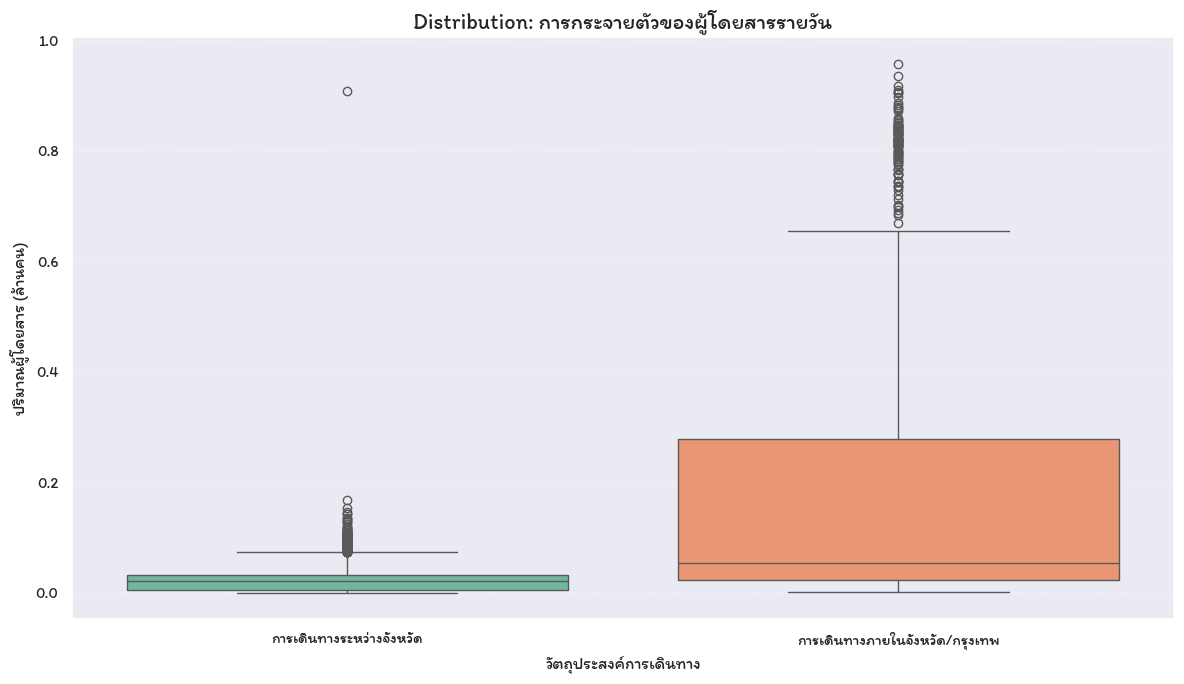


📊 สรุป KPI แยกตามวัตถุประสงค์ (หน่วย: ล้านคน):


,วัตถุประสงค์,เฉลี่ยรายวัน (ล้านคน),ค่ามัธยฐาน (ล้านคน),ความผันผวน (Std),สูงสุดต่อวัน (ล้านคน),ยอดรวมทั้งหมด (ล้านคน)
0,การเดินทางภายในจังหวัด/กรุงเทพ,0.17,0.05,0.22,0.96,438.93
1,การเดินทางระหว่างจังหวัด,0.03,0.02,0.04,0.91,48.85



💡 ความน่าสนใจ:
ตลอด 2 ปี มีการเดินทางในกรุงเทพฯ รวมทั้งสิ้น 438.93 ล้านคน
มากกว่าการเดินทางระหว่างจังหวัดถึง 9.0 เท่า!


In [ ]:
# =============================================================
# CELL 14: วิเคราะห์การกระจายตัว (Distribution) ของผู้โดยสาร
# แยกตาม 'วัตถุประสงค์การเดินทาง' (กรุงเทพฯ vs ระหว่างจังหวัด)
#
# ขั้นตอน:
#   1. กรองข้อมูลเฉพาะ 2 วัตถุประสงค์หลัก + หน่วย = 'คน'
#   2. สร้าง Box Plot แสดงการกระจายตัว
#   3. คำนวณและแสดง KPI สรุป
# =============================================================

# 1. กรองเฉพาะ 2 วัตถุประสงค์หลัก และหน่วยเป็น 'คน' เท่านั้น
#    (หน่วยอื่น เช่น 'เที่ยว' หรือ 'เที่ยวบิน' จะทำให้ค่าเพี้ยน)
purposes = ['การเดินทางภายในจังหวัด/กรุงเทพ', 'การเดินทางระหว่างจังหวัด']
df_filtered = df[(df['วัตถุประสงค์'].isin(purposes)) & (df['หน่วย'] == 'คน')].copy()

# --- ส่วนสำคัญ: ปรับหน่วยให้เป็น 'ล้านคน' เพื่อให้อ่านง่ายขึ้น ---
# สร้างคอลัมน์ใหม่เพื่อไม่ให้ทับข้อมูลดิบ (ตามหลัก Non-Destructive)
df_filtered['ปริมาณ_ล้านคน'] = df_filtered['ปริมาณ'] / 1_000_000

# --- ส่วนที่ 1: สร้าง Box Plot แสดง Distribution ---
# Box Plot ดีกว่า Bar Chart ตรงที่แสดง Median, IQR, และ Outliers ได้ในครั้งเดียว
plt.figure(figsize=(12, 7))
sns.boxplot(data=df_filtered, x='วัตถุประสงค์', y='ปริมาณ_ล้านคน', palette='Set2', showfliers=True)

plt.title('Distribution: การกระจายตัวของผู้โดยสารรายวัน', fontsize=16, fontweight='bold')
plt.xlabel('วัตถุประสงค์การเดินทาง', fontsize=12)
plt.ylabel('ปริมาณผู้โดยสาร (ล้านคน)', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# --- ส่วนที่ 2: คำนวณ KPI สรุป ---
print("\n📊 สรุป KPI แยกตามวัตถุประสงค์ (หน่วย: ล้านคน):")

# groupby + agg → สรุปสถิติหลักสำหรับแต่ละกลุ่มวัตถุประสงค์
kpi_summary = df_filtered.groupby('วัตถุประสงค์')['ปริมาณ_ล้านคน'].agg([
    'mean',   # ค่าเฉลี่ย
    'median', # ค่ามัธยฐาน
    'std',    # ความผันผวน (Standard Deviation)
    'max',    # ยอดสูงสุดในหนึ่งวัน
    'sum'     # ยอดรวมทั้งหมด (ทั้งปี 68-69)
]).reset_index()

# เปลี่ยนชื่อคอลัมน์ให้เป็นภาษาไทยที่เข้าใจง่าย
kpi_summary.columns = [
    'วัตถุประสงค์',
    'เฉลี่ยรายวัน (ล้านคน)',
    'ค่ามัธยฐาน (ล้านคน)',
    'ความผันผวน (Std)',
    'สูงสุดต่อวัน (ล้านคน)',
    'ยอดรวมทั้งหมด (ล้านคน)'
]

# ตั้งค่าการแสดงผลตัวเลขทศนิยม 2 ตำแหน่งและใส่คอมม่าคั่น
pd.options.display.float_format = '{:,.2f}'.format
display(kpi_summary)

# --- ส่วนเสริม: แสดง Insight สั้นๆ ---
# .values[0] → ดึงค่าตัวแรกออกมาเป็น scalar (ไม่ใช่ Series)
total_bkk = kpi_summary.loc[kpi_summary['วัตถุประสงค์'] == 'การเดินทางภายในจังหวัด/กรุงเทพ', 'ยอดรวมทั้งหมด (ล้านคน)'].values[0]
total_inter = kpi_summary.loc[kpi_summary['วัตถุประสงค์'] == 'การเดินทางระหว่างจังหวัด', 'ยอดรวมทั้งหมด (ล้านคน)'].values[0]

print(f"\n💡 ความน่าสนใจ:")
print(f"ตลอด 2 ปี มีการเดินทางในกรุงเทพฯ รวมทั้งสิ้น {total_bkk:.2f} ล้านคน")
print(f"มากกว่าการเดินทางระหว่างจังหวัดถึง {total_bkk/total_inter:.1f} เท่า!")


📑 สรุปผลการวิเคราะห์โครงสร้างและพฤติกรรมการเดินทาง (ปี 68-69)

3. สัดส่วนรูปแบบการเดินทาง (Modal Share): "ทางราง" คือส่วนสำคัญ
จากกราฟ Stacked Bar Chart พบสัดส่วนที่น่าสนใจดังนี้:

* กรุงเทพฯ พึ่งพารถไฟฟ้าเป็นหลัก: มีสัดส่วนการเดินทาง ทางรางสูงถึง 56.96% ซึ่งเป็นคำตอบของการเดินทางที่เลี่ยงปัญหารถติดได้ดีที่สุด

* ทางถนนคือฐานรากที่ขาดไม่ได้: ทั้งสองกลุ่มมีสัดส่วนการใช้ทางถนนใกล้เคียงกันที่ 33-37%  
  * ในเมือง: ทำหน้าที่เป็นระบบเชื่อมต่อกับสถานที่ต่างๆ

  * ระหว่างจังหวัด: ทำหน้าที่เป็นระบบขนส่งหลักในพื้นที่ที่รถไฟหรือเครื่องบินเข้าไม่ถึง

* การแข่งขันระหว่างจังหวัด: ทางอากาศ (34.75%) มีส่วนแบ่งใกล้เคียงกับทางถนน แสดงถึงความนิยมในการเดินทางระยะไกลที่เน้นความรวดเร็ว

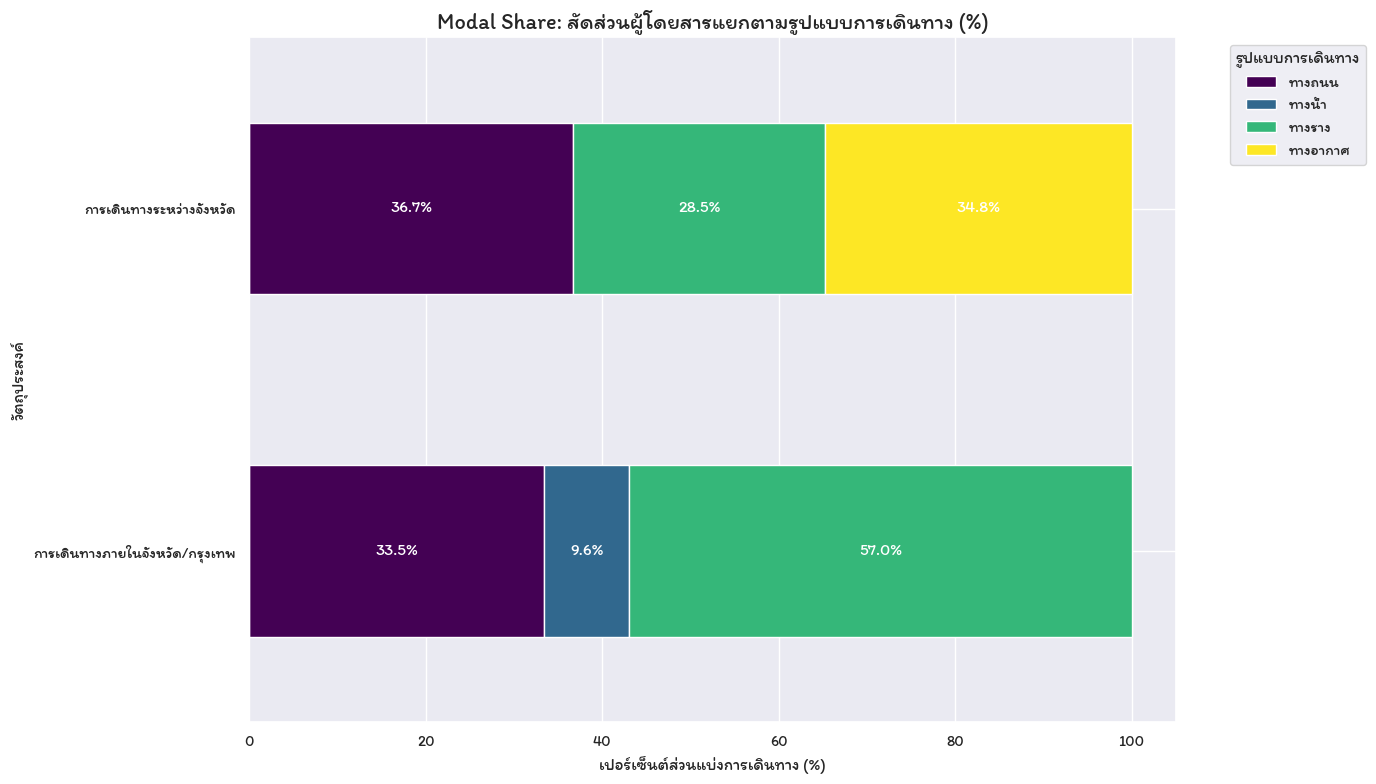

📊 ตารางสรุปสัดส่วนรูปแบบการเดินทาง (เฉพาะหน่วย: คน) [%]:


รูปแบบการเดินทาง,ทางถนน,ทางน้ำ,ทางราง,ทางอากาศ
วัตถุประสงค์,,,,
การเดินทางภายในจังหวัด/กรุงเทพ,33.45,9.59,56.96,0.00
การเดินทางระหว่างจังหวัด,36.73,0.00,28.52,34.75


In [ ]:
# =============================================================
# CELL 15: วิเคราะห์ Modal Share (สัดส่วนรูปแบบการเดินทาง)
#
# เป้าหมาย: ดูว่าแต่ละวัตถุประสงค์ใช้ 'รูปแบบการเดินทาง' (ทางราง/ถนน/อากาศ)
#           ในสัดส่วนเท่าไร → Stacked Bar Chart (Normalized 100%)
#
# ขั้นตอน:
#   1. กรองเฉพาะ หน่วย = 'คน' เพื่อให้บวกกันได้อย่างถูกต้อง
#   2. groupby + unstack → สร้าง Pivot Table
#   3. Normalize เป็น %
#   4. Plot Stacked Bar Chart
# =============================================================

# 1. กรองเอาเฉพาะหน่วย 'คน' ก่อนเอาไปบวกกัน
#    (ถ้าไม่กรอง ค่าที่หน่วยต่างกันจะถูกบวกรวมกันผิดๆ)
df_people = df[df['หน่วย'] == 'คน']

# 2. รวมยอดผู้โดยสาร แยกตาม 'วัตถุประสงค์' และ 'รูปแบบการเดินทาง'
#    unstack() → แปลง Multi-Index เป็น Wide format (แต่ละ 'รูปแบบ' เป็น column)
#    fillna(0) → เติม 0 ในช่องที่ไม่มีข้อมูล
mode_by_purpose = df_people.groupby(['วัตถุประสงค์', 'รูปแบบการเดินทาง'])['ปริมาณ'].sum().unstack().fillna(0)

# 3. กรองเฉพาะ 2 วัตถุประสงค์หลัก
#    .reindex() → ป้องกัน KeyError ถ้าชื่อวัตถุประสงค์ไม่มีในข้อมูล
target_purposes = ['การเดินทางภายในจังหวัด/กรุงเทพ', 'การเดินทางระหว่างจังหวัด']
mode_by_purpose = mode_by_purpose.reindex(target_purposes).fillna(0)

# 4. แปลงเป็น % (Normalized) → หาร Row ด้วยผลรวมของ Row นั้น
mode_by_purpose_pct = mode_by_purpose.div(mode_by_purpose.sum(axis=1), axis=0) * 100

# 5. สร้าง Stacked Bar Chart แนวนอน (barh)
ax = mode_by_purpose_pct.plot(kind='barh', stacked=True, figsize=(14, 8), colormap='viridis')

plt.title('Modal Share: สัดส่วนผู้โดยสารแยกตามรูปแบบการเดินทาง (%)', fontsize=16)
plt.xlabel('เปอร์เซ็นต์ส่วนแบ่งการเดินทาง (%)', fontsize=12)
plt.ylabel('วัตถุประสงค์', fontsize=12)
plt.legend(title='รูปแบบการเดินทาง', bbox_to_anchor=(1.05, 1), loc='upper left')

# ใส่ตัวเลข % กำกับในกราฟ (แสดงเฉพาะส่วนที่กว้างกว่า 3% เพื่อไม่ให้รก)
for p in ax.patches:
    width = p.get_width()
    if width > 3:  # แสดงเฉพาะแท่งที่กว้างกว่า 3% เพื่อให้อ่านง่าย
        ax.annotate(f'{width:.1f}%',
                    (p.get_x() + width/2, p.get_y() + p.get_height()/2),
                    ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

# 6. แสดงตารางตัวเลขเพื่อความแม่นยำ
print("📊 ตารางสรุปสัดส่วนรูปแบบการเดินทาง (เฉพาะหน่วย: คน) [%]:")
display(mode_by_purpose_pct.round(2))


# ข้อที่ 1 คนไทยเดินทางด้วยอะไรมากที่สุด?

จากข้อมูลปริมาณผู้โดยสารของระบบขนส่งทั้ง **4 รูปแบบหลัก**

* รถไฟฟ้า BTS
* รถไฟฟ้า MRT
* Airport Rail Link
* รถไฟชานเมืองสายสีแดง

จงสร้างกราฟที่แสดงให้เห็นว่า
* สัดส่วนการใช้ระบบขนส่งแต่ละประเภทเป็นอย่างไร
* และรูปแบบใดที่ เติบโตหรือหดตัวมากที่สุด เมื่อเปรียบเทียบปี 2568 กับ 2569

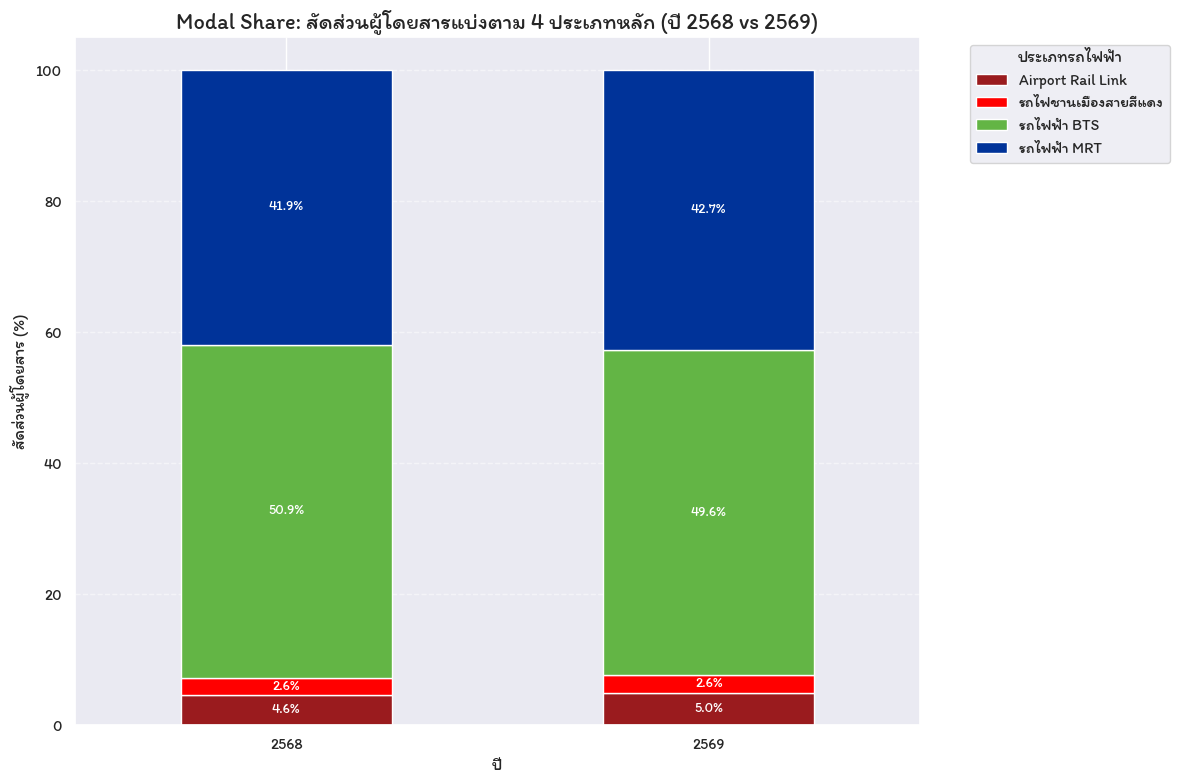

In [ ]:
# =============================================================
# CELL 16: วิเคราะห์ Market Share รถไฟฟ้า 4 ประเภทหลัก
#          เปรียบเทียบปี 2568 vs 2569 (Stacked Bar)
#
# ขั้นตอน:
#   1. สร้าง Mapping เพื่อยุบสายย่อย MRT → กลุ่มเดียว
#   2. กรองข้อมูลและสร้าง Pivot Table แยกตามปี
#   3. คำนวณสัดส่วน % และ Plot
# =============================================================

# 1. กำหนด Mapping เพื่อรวมกลุ่มรถไฟฟ้า (Grouping)
#    ยุบสายสีน้ำเงิน, ม่วง, เหลือง, ชมพู ให้เป็น 'รถไฟฟ้า MRT' ทั้งหมด
#    เหตุผล: ต้องการเปรียบเทียบในระดับองค์กร (BMCL/BEM) ไม่ใช่รายสาย
rail_mapping = {
    'รถไฟฟ้า BTS': 'รถไฟฟ้า BTS',
    'รถไฟฟ้าสายสีน้ำเงิน': 'รถไฟฟ้า MRT',
    'รถไฟฟ้าสายสีม่วง': 'รถไฟฟ้า MRT',
    'รถไฟฟ้าสายสีเหลือง': 'รถไฟฟ้า MRT',
    'รถไฟฟ้าสายสีชมพู': 'รถไฟฟ้า MRT',
    'รถไฟฟ้า ARL': 'Airport Rail Link',
    'รถไฟฟ้าสายสีแดง': 'รถไฟชานเมืองสายสีแดง'
}

# 2. กรองข้อมูลเฉพาะสายที่เราสนใจ และหน่วยเป็น 'คน'
df_rail = df[df['ยานพาหนะ/ท่า'].isin(rail_mapping.keys()) & (df['หน่วย'] == 'คน')].copy()

# ใช้ .map() แปลงชื่อในคอลัมน์ให้เป็นกลุ่มใหม่ตาม Dictionary
df_rail['กลุ่มรถไฟฟ้า'] = df_rail['ยานพาหนะ/ท่า'].map(rail_mapping)

# สกัดปี (ค.ศ.) ออกมาเป็นคอลัมน์ใหม่ เพื่อใช้ groupby
df_rail['ปี'] = df_rail['วันที่'].dt.year

# 3. รวมยอดผู้โดยสารแยกตามปีและ 'กลุ่มรถไฟฟ้า'
#    .unstack() → ทำให้ 'กลุ่มรถไฟฟ้า' กลายเป็น column
#    fill_value=0 → เติม 0 แทน NaN ในช่องที่ไม่มีข้อมูล
passenger_volume_by_year_vehicle = df_rail.groupby(['ปี', 'กลุ่มรถไฟฟ้า'])['ปริมาณ'].sum().unstack(fill_value=0)

# คำนวณสัดส่วน % แต่ละปี (หารด้วยผลรวมรายปี)
proportions = passenger_volume_by_year_vehicle.div(passenger_volume_by_year_vehicle.sum(axis=1), axis=0) * 100

# --- กำหนดสีประจำกลุ่ม (Official Brand Colors) ---
group_colors_map = {
    'รถไฟฟ้า BTS': '#63B545',            # เขียว BTS
    'รถไฟฟ้า MRT': '#003399',            # น้ำเงิน MRT (เป็นตัวแทนกลุ่ม)
    'Airport Rail Link': '#9A1B1E',      # แดงเลือดหมู ARL
    'รถไฟชานเมืองสายสีแดง': '#FF0000'    # แดงสด สายสีแดง
}

# ดึงสีตามลำดับ column ใน proportions
current_colors = [group_colors_map.get(col, '#808080') for col in proportions.columns]

# --- Plot: Stacked Bar Chart เปรียบเทียบ 2 ปี ---
plt.figure(figsize=(12, 8))
ax1 = proportions.plot(kind='bar', stacked=True, ax=plt.gca(), color=current_colors, edgecolor='white', linewidth=1)

plt.title('Modal Share: สัดส่วนผู้โดยสารแบ่งตาม 4 ประเภทหลัก (ปี 2568 vs 2569)', fontsize=16, fontweight='bold')
plt.xlabel('ปี', fontsize=12)
plt.ylabel('สัดส่วนผู้โดยสาร (%)', fontsize=12)
plt.xticks([0, 1], ['2568', '2569'], rotation=0)  # แสดงป้ายปี พ.ศ. แทน ค.ศ.
plt.legend(title='ประเภทรถไฟฟ้า', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# ใส่ตัวเลข % กำกับกลางแท่ง (แสดงเฉพาะ > 1% เพื่อไม่ให้รก)
for n, x in enumerate([*proportions.index.values]):
    for (proportion, y_loc) in zip(proportions.loc[x], proportions.loc[x].cumsum()):
        if proportion > 1:
            plt.text(x=n, y=(y_loc - proportion/2), s=f'{proportion:.1f}%',
                     color="white", fontsize=10, fontweight='bold', ha="center", va="center")

plt.tight_layout()
plt.show()


**รถไฟฟ้า BTS คือ "เจ้าตลาดที่มีโครงข่ายครอบคลุมที่สุด"**

* สัดส่วน: ครองส่วนแบ่งการตลาดสูงที่สุดอยู่ที่ประมาณ 50% ทั้ง 2 ปี

BTS ยังคงเป็นโครงข่ายหลักที่คนกรุงเทพฯ ใช้เดินทางมากที่สุด คิดเป็นเกือบครึ่งหนึ่งของคนใช้รถไฟฟ้าทั้งหมดในระบบ


---


**รถไฟฟ้า MRT: "กลุ่มที่มีเสถียรภาพและเติบโตในเชิงสัดส่วน"**

* สัดส่วน: ครองส่วนแบ่งการตลาดสูงที่สุดอยู่ที่ประมาณ 40% ทั้ง 2 ปี

การที่สัดส่วน % ของ MRT เพิ่มขึ้น สวนทางกับกลุ่มอื่น สะท้อนให้เห็นว่าโครงข่าย MRT (ซึ่งรวมสายสีน้ำเงิน ม่วง เหลือง ชมพู) เริ่มมีความแข็งแกร่งและดึงดูดผู้โดยสารได้มากขึ้นเรื่อยๆ จากความครอบคลุมของเส้นทาง

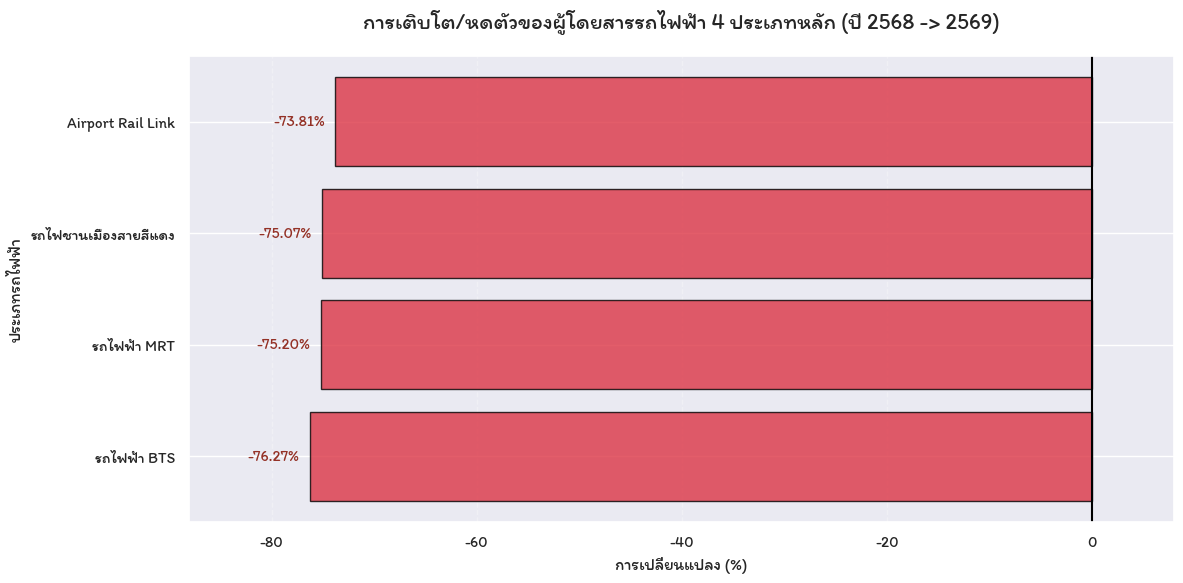

In [ ]:
# =============================================================
# CELL 17: Diverging Bar Chart - การเติบโต/หดตัว ปี 68 → 69
#
# สูตร: Growth (%) = (ยอด_2569 - ยอด_2568) / ยอด_2568 * 100
# แท่งสีเขียว = เติบโต (บวก), แท่งสีแดง = หดตัว (ลบ)
#
# หมายเหตุ: ใช้ปี ค.ศ. (2025, 2026) เพราะ Pandas แปลง พ.ศ. → ค.ศ. แล้ว
#           (ตรวจสอบผ่าน fix_buddhist_year ใน Cell 11)
# =============================================================

# ตรวจสอบก่อนว่ามีทั้ง 2 ปีในข้อมูลหรือไม่ (ป้องกัน KeyError)
if 2025 in passenger_volume_by_year_vehicle.index and 2026 in passenger_volume_by_year_vehicle.index:
    # 1. คำนวณ Growth Rate จากข้อมูลที่ 'ยุบกลุ่มแล้ว' (4 ประเภท)
    #    passenger_volume_by_year_vehicle คือตัวที่ถูก group มาจาก Cell ก่อนหน้า
    v2568 = passenger_volume_by_year_vehicle.loc[2025]   # ยอดปี 2568 (ค.ศ. 2025)
    v2569 = passenger_volume_by_year_vehicle.loc[2026]   # ยอดปี 2569 (ค.ศ. 2026)
    growth_4_types = ((v2569 - v2568) / v2568 * 100).fillna(0)  # fillna(0) ป้องกัน division by zero

    # 2. เรียงลำดับจากน้อยไปมาก (barh: ค่ามากสุดจะอยู่บนสุด)
    df_growth = growth_4_types.sort_values(ascending=True).to_frame(name='percent_change')

    plt.figure(figsize=(12, 6))

    # 3. กำหนดสีตามค่า: เขียว = บวก, แดง = ลบ
    colors = ['#28A745' if x > 0 else '#DC3545' for x in df_growth['percent_change']]

    # 4. สร้างกราฟแท่งแนวนอน (Horizontal Bar)
    bars = plt.barh(df_growth.index, df_growth['percent_change'], color=colors, edgecolor='black', alpha=0.8)

    # 5. ตกแต่งกราฟ
    plt.title('การเติบโต/หดตัวของผู้โดยสารรถไฟฟ้า 4 ประเภทหลัก (ปี 2568 -> 2569)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('การเปลี่ยนแปลง (%)', fontsize=12)
    plt.ylabel('ประเภทรถไฟฟ้า', fontsize=12)

    # เส้นแกนกลางที่ 0 (เพื่อแยกบวก/ลบ)
    plt.axvline(0, color='black', linestyle='-', linewidth=1.5)

    # ใส่ตัวเลข % กำกับที่ปลายแท่ง
    for bar in bars:
        width = bar.get_width()
        # กำหนดตำแหน่งเลข: ถ้าบวกวางขวา ถ้าลบวางซ้าย
        ha_val = 'left' if width > 0 else 'right'
        offset = 1 if width > 0 else -1

        plt.text(width + offset, bar.get_y() + bar.get_height()/2,
                 f'{width:+.2f}%',    # + แสดงเครื่องหมาย +/- เสมอ
                 va='center', ha=ha_val,
                 fontsize=11, fontweight='bold',
                 color='#196F3D' if width > 0 else '#943126')  # สีเข้มขึ้นเพื่อให้อ่านบนพื้นขาว

    # เพิ่ม margin ขวา-ซ้ายเพื่อให้ตัวเลขไม่เกิน frame
    xmin, xmax = plt.xlim()
    plt.xlim(xmin - 8, xmax + 8)

    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    # แจ้งเตือนถ้าข้อมูลไม่ครบทั้ง 2 ปี
    print("⚠️ ข้อมูลปี 2568 หรือ 2569 ไม่เพียงพอสำหรับการเปรียบเทียบ")


**ทุกรูปแบบการเดินทางมีสภาวะ "หดตัวมหาศาล" ในระดับที่ใกล้เคียงกัน**
แต่ถ้าจะระบุว่ารูปแบบใดได้รับผลกระทบมากหรือน้อยที่สุด มีรายละเอียดดังนี้

1. รถไฟฟ้า BTS (-76.27%)
2. รถไฟฟ้า MRT (-75.20%)
3. รถไฟชานเมืองสายสีแดง	(-75.07%)

In [ ]:
# =============================================================
# CELL 18: สร้างตารางสรุปปริมาณผู้โดยสาร + สัดส่วน + การเติบโต
#          สำหรับรถไฟฟ้า 4 ประเภทหลัก ปี 2568 vs 2569
# =============================================================

print("\n" + "="*60)
print("📊 ตารางสรุปปริมาณผู้โดยสารและสัดส่วนรายปี (4 ประเภทหลัก)")
print("="*60)

# 1. เตรียมข้อมูลปี 2568 (ค.ศ. 2025)
#    ตรวจสอบก่อนเพื่อป้องกัน KeyError
if 2025 in passenger_volume_by_year_vehicle.index:
    # ยอดรวมในหน่วยล้านคน (หาร 1,000,000)
    vol_2568 = (passenger_volume_by_year_vehicle.loc[2025] / 1_000_000).round(2)
    # สัดส่วน % ที่คำนวณไว้แล้วใน Cell ก่อนหน้า
    prop_2568 = proportions.loc[2025].round(2)

    # รวมทั้งยอดและสัดส่วนไว้ใน DataFrame เดียว
    s2568 = pd.concat([vol_2568, prop_2568], axis=1)
    s2568.columns = ['ปี 2568: ล้านคน', 'ปี 2568: สัดส่วน %']
else:
    s2568 = pd.DataFrame()

# 2. เตรียมข้อมูลปี 2569 (ค.ศ. 2026)
if 2026 in passenger_volume_by_year_vehicle.index:
    vol_2569 = (passenger_volume_by_year_vehicle.loc[2026] / 1_000_000).round(2)
    prop_2569 = proportions.loc[2026].round(2)

    s2569 = pd.concat([vol_2569, prop_2569], axis=1)
    s2569.columns = ['ปี 2569: ล้านคน', 'ปี 2569: สัดส่วน %']
else:
    s2569 = pd.DataFrame()

# 3. รวมตาราง 2 ปีเข้าด้วยกัน (axis=1 = เพิ่ม column ข้างๆ)
final_summary = pd.concat([s2568, s2569], axis=1).fillna(0)
display(final_summary)

# 4. แสดงตารางการเติบโต (%)
if 2025 in passenger_volume_by_year_vehicle.index and 2026 in passenger_volume_by_year_vehicle.index:
    print("\n📈 สรุปการเปลี่ยนแปลง (%) ปี 2568 เทียบกับ 2569 (4 ประเภทหลัก):")

    # คำนวณ Growth Rate สำหรับ 4 กลุ่ม
    v1 = passenger_volume_by_year_vehicle.loc[2025]
    v2 = passenger_volume_by_year_vehicle.loc[2026]
    final_growth = ((v2 - v1) / v1 * 100).round(2).to_frame(name='การเปลี่ยนแปลง (%)')

    # เรียงจากมากไปน้อย (ค่าบวก/โตมากสุดอยู่บน)
    display(final_growth.sort_values(by='การเปลี่ยนแปลง (%)', ascending=False))



📊 ตารางสรุปปริมาณผู้โดยสารและสัดส่วนรายปี (4 ประเภทหลัก)


,ปี 2568: ล้านคน,ปี 2568: สัดส่วน %,ปี 2569: ล้านคน,ปี 2569: สัดส่วน %
กลุ่มรถไฟฟ้า,,,,
Airport Rail Link,9.28,4.62,2.43,4.97
รถไฟชานเมืองสายสีแดง,5.19,2.58,1.29,2.64
รถไฟฟ้า BTS,102.32,50.88,24.28,49.64
รถไฟฟ้า MRT,84.30,41.92,20.90,42.74



📈 สรุปการเปลี่ยนแปลง (%) ปี 2568 เทียบกับ 2569 (4 ประเภทหลัก):


,การเปลี่ยนแปลง (%)
กลุ่มรถไฟฟ้า,
Airport Rail Link,-73.81
รถไฟชานเมืองสายสีแดง,-75.07
รถไฟฟ้า MRT,-75.20
รถไฟฟ้า BTS,-76.27


# ข้อ 2 — รถไฟฟ้าในกรุงเทพฯ แต่ละสายมีพฤติกรรมผู้โดยสารต่างกันอย่างไร?

จากข้อมูลผู้โดยสารรถไฟฟ้าทุกสาย

* BTS
* MRT สีน้ำเงิน
* MRT สีม่วง
* MRT สีเหลือง
* MRT สีชมพู
* Airport Rail Link
* รถไฟชานเมืองสายสีแดง

จงสร้างกราฟที่เปรียบเทียบ
* ปริมาณผู้โดยสารของแต่ละสาย
* และรูปแบบการเปลี่ยนแปลงของผู้โดยสารรายวัน

พร้อมวิเคราะห์ว่าสายใดมี
* ความผันผวนของผู้โดยสารสูง
* สายใดมี ฐานผู้โดยสารที่เสถียร

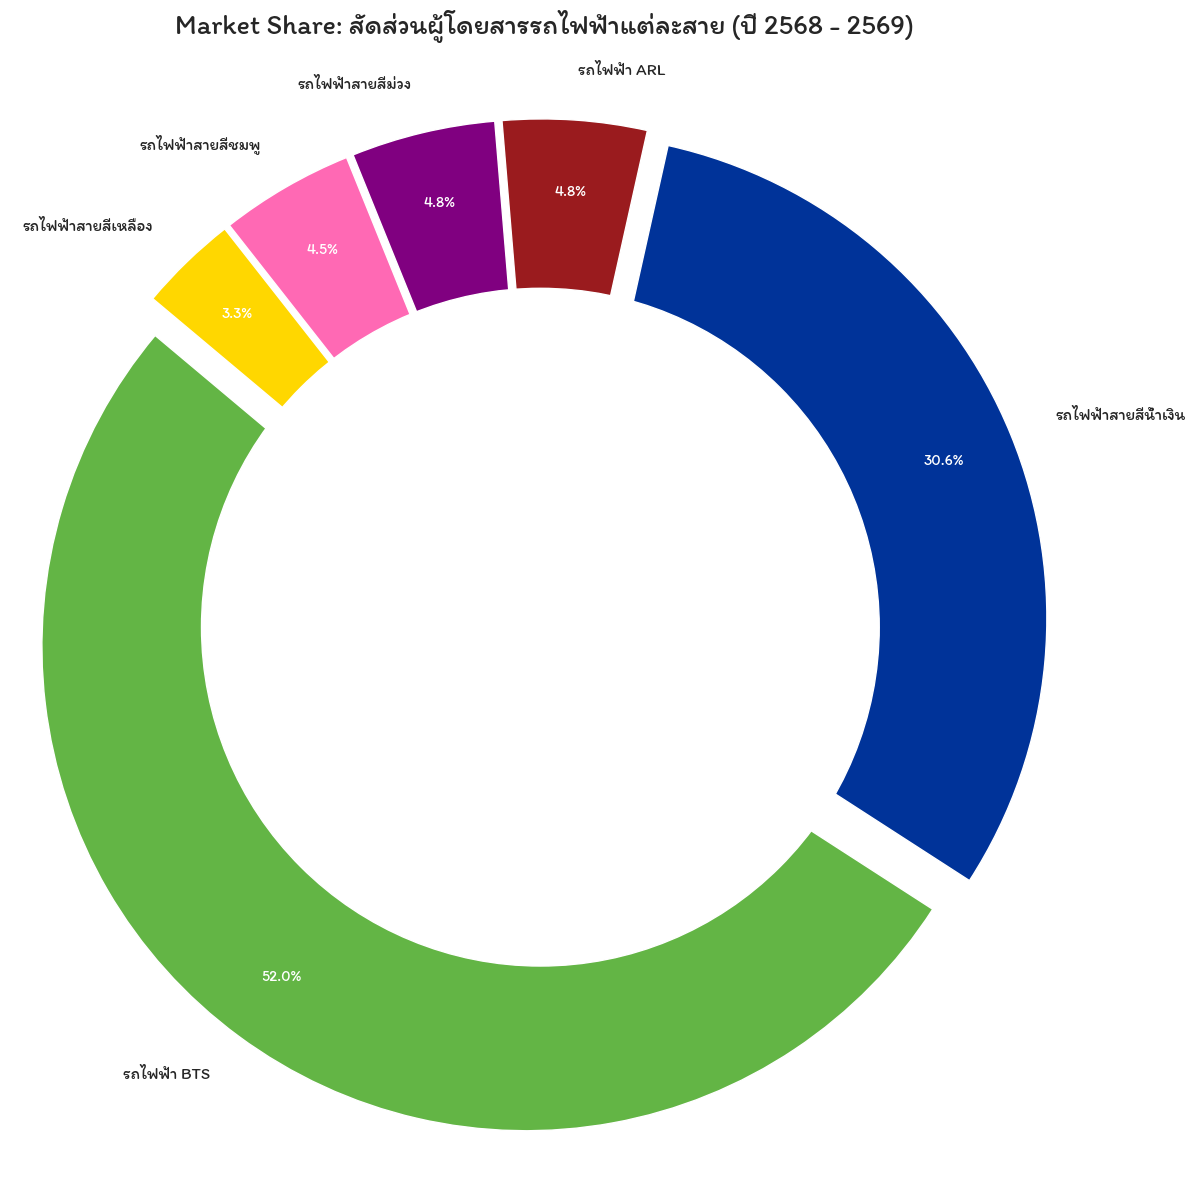


📊 สรุปยอดผู้โดยสารสะสมและสัดส่วนเปอร์เซ็นต์


,รวมผู้โดยสาร (คน),สัดส่วน (%)
ยานพาหนะ/ท่า,,
รถไฟฟ้า BTS,"126,595,162.00",51.99
รถไฟฟ้าสายสีน้ำเงิน,"74,596,244.00",30.63
รถไฟฟ้า ARL,"11,714,187.00",4.81
รถไฟฟ้าสายสีม่วง,"11,701,209.00",4.81
รถไฟฟ้าสายสีชมพู,"10,871,430.00",4.46
รถไฟฟ้าสายสีเหลือง,"8,039,158.00",3.30


In [ ]:
# =============================================================
# CELL 19: Market Share รายสาย - Donut Chart
#
# วิเคราะห์สัดส่วนผู้โดยสารของรถไฟฟ้าแต่ละสาย (7 สาย)
# ใช้ Donut Chart (Pie + วงกลมตรงกลาง) อ่านง่ายกว่า Pie ปกติ
# =============================================================

# กำหนดรายการรถไฟฟ้าแต่ละสายที่ต้องการวิเคราะห์
rail_vehicles_individual = [
    'รถไฟฟ้า BTS',
    'รถไฟฟ้าสายสีน้ำเงิน',
    'รถไฟฟ้าสายสีม่วง',
    'รถไฟฟ้าสายสีเหลือง',
    'รถไฟฟ้าสายสีชมพู',
    'รถไฟฟ้า ARL',
    'รถไฟชานเมืองสายสีแดง'
]

# กรองข้อมูลเฉพาะรถไฟฟ้าแต่ละสายที่ระบุ และหน่วยเป็น 'คน'
df_individual_rail = df[
    (df['ยานพาหนะ/ท่า'].isin(rail_vehicles_individual)) &
    (df['หน่วย'] == 'คน')
].copy()

# ตรวจสอบและแปลง Data Types เพื่อให้พร้อมใช้งาน
df_individual_rail['วันที่'] = pd.to_datetime(df_individual_rail['วันที่'])
df_individual_rail['ปริมาณ'] = pd.to_numeric(df_individual_rail['ปริมาณ'])

# รวมยอดผู้โดยสารรายวันของแต่ละสาย (ใช้สำหรับ Time Series ใน Cell ถัดไป)
daily_passengers_individual_rail = df_individual_rail.groupby(['วันที่', 'ยานพาหนะ/ท่า'])['ปริมาณ'].sum().reset_index()

# --- สร้าง Donut Chart ---

# 1. รวมยอดสะสม แยกตามสาย เรียงจากมากไปน้อย
pie_data = df_individual_rail.groupby('ยานพาหนะ/ท่า')['ปริมาณ'].sum().sort_values(ascending=False)

# 2. กำหนดสีให้ตรงกับสีประจำสาย (Official Brand Colors)
colors_map = {
    'รถไฟฟ้า BTS': '#63B545',            # สีเขียวสด
    'รถไฟฟ้าสายสีน้ำเงิน': '#003399',    # สีน้ำเงินเข้ม
    'รถไฟฟ้าสายสีม่วง': '#800080',       # สีม่วง
    'รถไฟฟ้าสายสีเหลือง': '#FFD700',     # สีเหลือง
    'รถไฟฟ้าสายสีชมพู': '#FF69B4',       # สีชมพู
    'รถไฟฟ้า ARL': '#9A1B1E',            # สีแดงเลือดหมู
    'รถไฟชานเมืองสายสีแดง': '#FF0000'    # สีแดงสด
}
# สร้าง list สีตามลำดับใน pie_data (ต้องตรงกับ index)
current_colors = [colors_map.get(line, '#808080') for line in pie_data.index]

# 3. สร้างกราฟ Pie Chart
plt.figure(figsize=(12, 12))
patches, texts, autotexts = plt.pie(
    pie_data,
    labels=pie_data.index,
    autopct='%1.1f%%',       # แสดงตัวเลขเปอร์เซ็นต์ (ทศนิยม 1 ตำแหน่ง)
    startangle=140,          # ปรับมุมเริ่มต้นให้ชิ้นใหญ่อยู่บน
    colors=current_colors,
    pctdistance=0.85,        # ระยะห่างตัวเลข % จากจุดศูนย์กลาง
    explode=[0.05] * len(pie_data),  # แยกชิ้นออกเล็กน้อยให้เห็นขอบชัด
    textprops={'fontsize': 12}
)

# ปรับตัวเลขเปอร์เซ็นต์ในกราฟให้ตัวหนาและสีขาว
plt.setp(autotexts, size=11, weight="bold", color="white")

# 4. วาดวงกลมสีขาวตรงกลาง → แปลง Pie เป็น Donut (อ่านง่ายกว่า)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# 5. ตกแต่งกราฟ
plt.title('Market Share: สัดส่วนผู้โดยสารรถไฟฟ้าแต่ละสาย (ปี 2568 - 2569)', fontsize=20, fontweight='bold', pad=30)
plt.axis('equal')  # ทำให้วงกลมออกมากลมดิก ไม่เบี้ยว
plt.tight_layout()
plt.show()

# --- ตารางสรุปประกอบกราฟ ---
print("\n" + "="*50)
print("📊 สรุปยอดผู้โดยสารสะสมและสัดส่วนเปอร์เซ็นต์")
print("="*50)
summary_table = pie_data.to_frame(name='รวมผู้โดยสาร (คน)')
summary_table['สัดส่วน (%)'] = (summary_table['รวมผู้โดยสาร (คน)'] / summary_table['รวมผู้โดยสาร (คน)'].sum() * 100).round(2)
display(summary_table.style.format('{:,.2f}'))


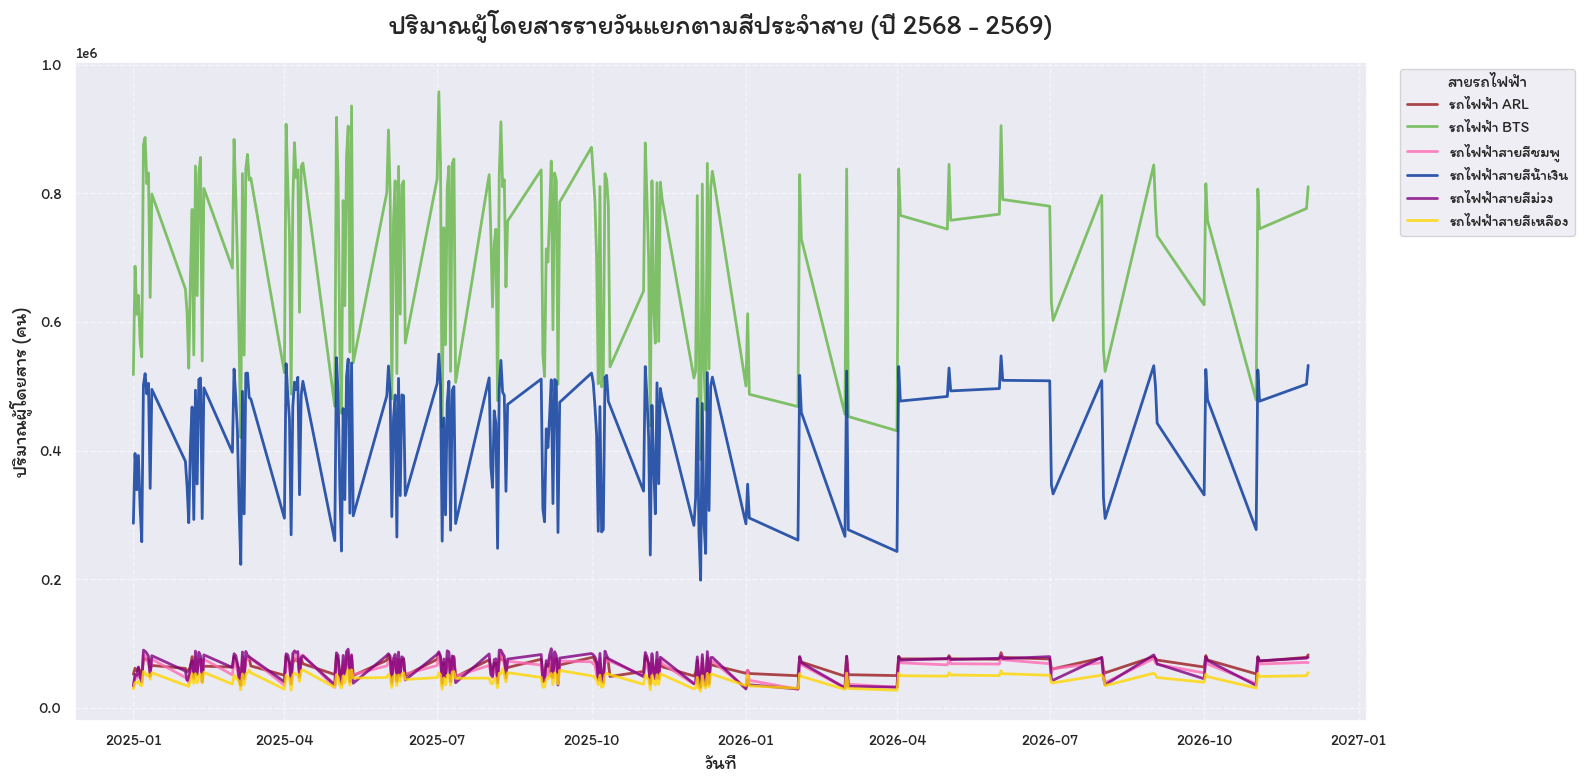

In [ ]:
# =============================================================
# CELL 20: Time Series - ปริมาณผู้โดยสารรายวันแต่ละสาย
#
# ใช้ Seaborn lineplot เพื่อดูแนวโน้มรายวัน
# palette=colors_map → บังคับสีให้ตรงกับสีประจำสาย
# =============================================================

# 1. กำหนด Mapping สีประจำสาย (Official Colors)
#    (ต้องกำหนดซ้ำใน Cell นี้เพราะ colors_map ในบางกรณีอาจถูกเขียนทับ)
colors_map = {
    'รถไฟฟ้า BTS': '#63B545',
    'รถไฟฟ้าสายสีน้ำเงิน': '#003399',
    'รถไฟฟ้าสายสีม่วง': '#800080',
    'รถไฟฟ้าสายสีเหลือง': '#FFD700',
    'รถไฟฟ้าสายสีชมพู': '#FF69B4',
    'รถไฟฟ้า ARL': '#9A1B1E',
    'รถไฟชานเมืองสายสีแดง': '#FF0000'
}

# 2. สร้างกราฟเส้น Time Series
plt.figure(figsize=(16, 8))

# palette=colors_map → Seaborn จะ map สีตามชื่อใน 'hue'
# lw=2 → ความหนาเส้น, alpha=0.8 → ความโปร่งใส
sns.lineplot(
    data=daily_passengers_individual_rail,
    x='วันที่',
    y='ปริมาณ',
    hue='ยานพาหนะ/ท่า',
    palette=colors_map,
    lw=2,
    alpha=0.8
)

# 3. ตกแต่งกราฟ
plt.title('ปริมาณผู้โดยสารรายวันแยกตามสีประจำสาย (ปี 2568 - 2569)', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('วันที่', fontsize=14)
plt.ylabel('ปริมาณผู้โดยสาร (คน)', fontsize=14)
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.5)

# วาง Legend ด้านนอกเพื่อไม่ให้ทับเส้นกราฟ
plt.legend(title='สายรถไฟฟ้า', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.show()


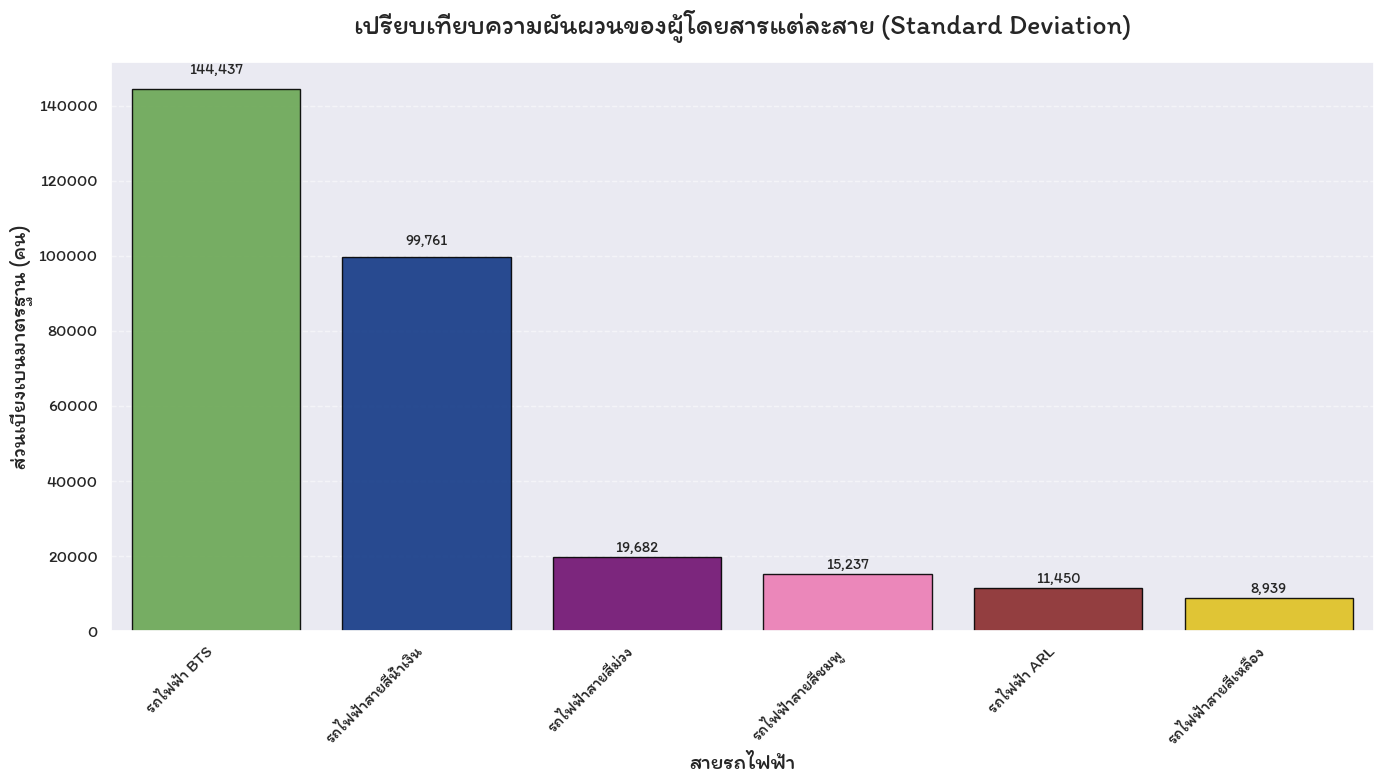

In [ ]:
# =============================================================
# CELL 21: เปรียบเทียบความผันผวน (Standard Deviation) แต่ละสาย
#
# Std สูง = ผู้โดยสารผันผวนมาก (คาดเดายาก)
# Std ต่ำ  = ผู้โดยสารค่อนข้างนิ่ง (เสถียร)
# =============================================================

plt.figure(figsize=(14, 8))

# 1. คำนวณค่าส่วนเบี่ยงเบนมาตรฐาน (Std) และเรียงจากมากไปน้อย
std_dev_by_line = daily_passengers_individual_rail.groupby('ยานพาหนะ/ท่า')['ปริมาณ'].std().sort_values(ascending=False)

# 2. ดึงสีจาก colors_map ให้ตรงกับลำดับข้อมูล
current_colors = [colors_map.get(line, '#808080') for line in std_dev_by_line.index]

# 3. สร้าง Bar Plot
#    palette ใน Seaborn ใหม่รองรับ list ของสีโดยตรง
sns.barplot(
    x=std_dev_by_line.index,
    y=std_dev_by_line.values,
    palette=current_colors,
    edgecolor='black',
    alpha=0.9
)

# 4. ตกแต่งกราฟ
plt.title('เปรียบเทียบความผันผวนของผู้โดยสารแต่ละสาย (Standard Deviation)', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('สายรถไฟฟ้า', fontsize=16)
plt.ylabel('ส่วนเบี่ยงเบนมาตรฐาน (คน)', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 5. ใส่ตัวเลขบนหัวแท่งเพื่อให้อ่านค่าได้ทันที
#    val*0.02 = เว้นระยะห่างเล็กน้อยจากหัวแท่ง
for i, val in enumerate(std_dev_by_line.values):
    plt.text(i, val + (val*0.02), f'{val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


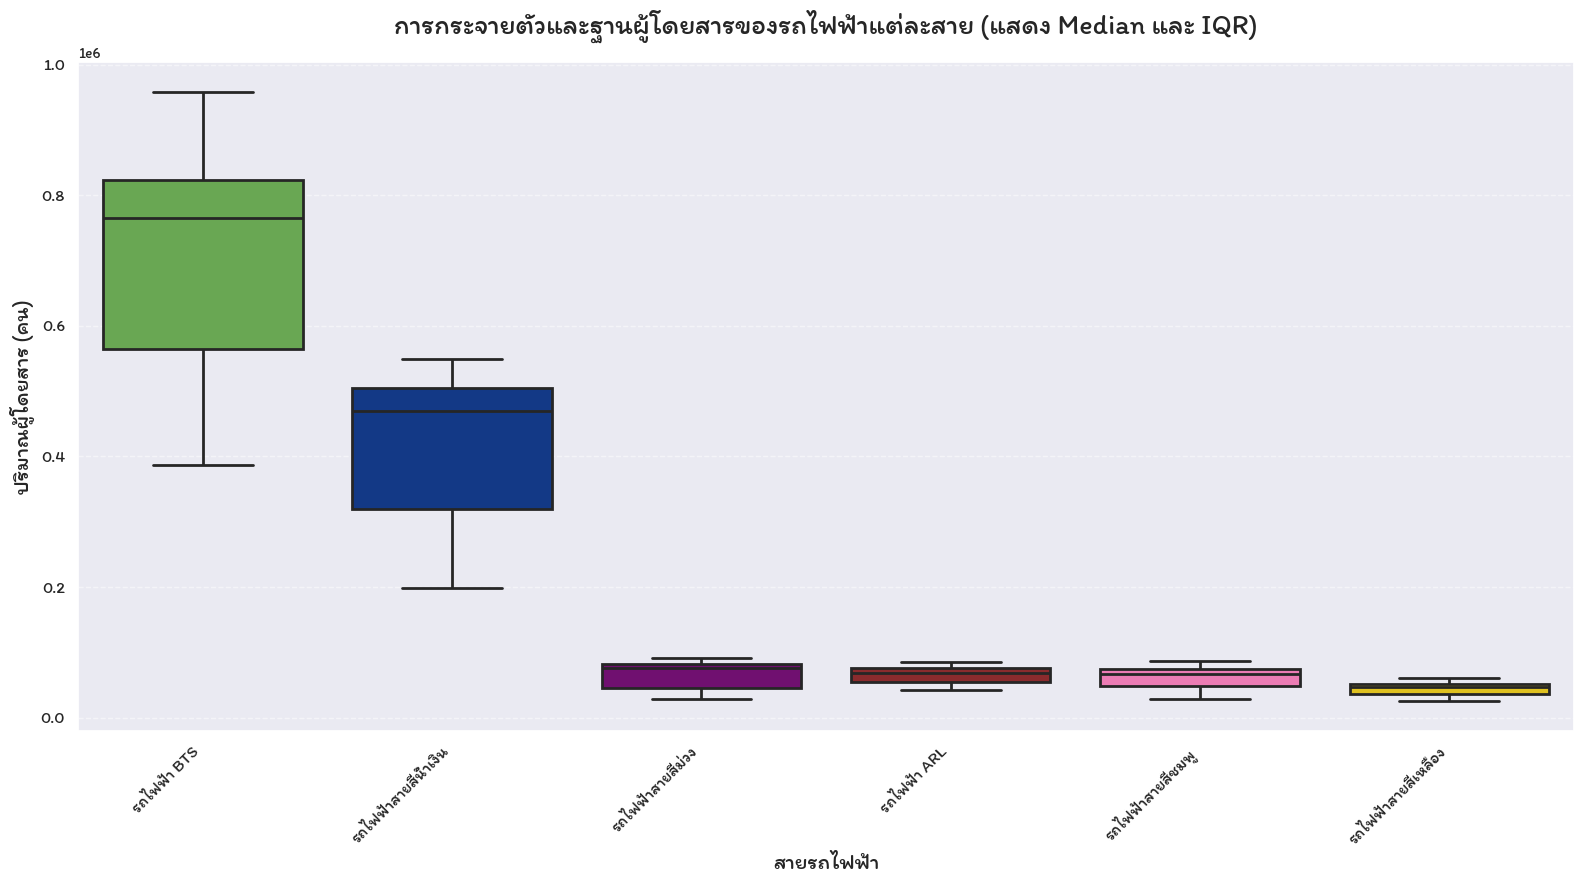


📊 สรุปสถิติรายวันและดัชนีความเสถียร (Coefficient of Variation)


,สายรถไฟฟ้า,เฉลี่ยรายวัน,มัธยฐานรายวัน,Std (ความผันผวน),ต่ำสุด,สูงสุด,CV (%) ความไม่เสถียร
1,รถไฟฟ้า BTS,"707,236","765,501","144,437","386,193","957,717",20.42%
3,รถไฟฟ้าสายสีน้ำเงิน,"419,080","469,664","99,761","198,521","549,926",23.80%
0,รถไฟฟ้า ARL,"65,810","69,038","11,450","42,340","85,741",17.40%
4,รถไฟฟ้าสายสีม่วง,"65,737","76,387","19,682","29,324","91,967",29.94%
2,รถไฟฟ้าสายสีชมพู,"61,075","66,598","15,237","29,075","86,750",24.95%
5,รถไฟฟ้าสายสีเหลือง,"45,164","47,704","8,939","25,795","61,133",19.79%


In [ ]:
# =============================================================
# CELL 22: Box Plot + สรุปสถิติ + Coefficient of Variation (CV)
#
# Box Plot → แสดง Median, IQR, Min/Max ของแต่ละสาย
# CV (%) = Std / Mean * 100
#   → ยิ่งน้อย = เสถียร, ยิ่งมาก = ผันผวน
#   → CV ดีกว่า Std ตรงที่ normalize ตามขนาด
#      (สายใหญ่มี Std สูงโดยธรรมชาติ CV จึงยุติธรรมกว่า)
# =============================================================

plt.figure(figsize=(16, 9))

# 1. เรียงลำดับ X-axis ตามค่ามัธยฐาน (มากสุดอยู่ซ้าย)
order_by_median = daily_passengers_individual_rail.groupby('ยานพาหนะ/ท่า')['ปริมาณ'].median().sort_values(ascending=False).index

# 2. ดึงสีตามลำดับที่เรียงแล้ว
current_colors = [colors_map.get(line, '#808080') for line in order_by_median]

# 3. สร้าง Box Plot
#    showfliers=False → ซ่อน Outlier เพื่อให้เห็นกล่อง IQR ชัดขึ้น
sns.boxplot(
    data=daily_passengers_individual_rail,
    x='ยานพาหนะ/ท่า',
    y='ปริมาณ',
    order=order_by_median,
    palette=current_colors,
    showfliers=False,
    linewidth=2
)

plt.title('การกระจายตัวและฐานผู้โดยสารของรถไฟฟ้าแต่ละสาย (แสดง Median และ IQR)', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('สายรถไฟฟ้า', fontsize=16)
plt.ylabel('ปริมาณผู้โดยสาร (คน)', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- คำนวณ CV และแสดงตารางสรุปสถิติ ---
print("\n" + "="*85)
print("📊 สรุปสถิติรายวันและดัชนีความเสถียร (Coefficient of Variation)")
print("="*85)

# รวมสถิติหลักด้วย .agg()
stats_summary = daily_passengers_individual_rail.groupby('ยานพาหนะ/ท่า')['ปริมาณ'].agg([
    'mean', 'median', 'std', 'min', 'max'
]).reset_index()

# CV (%) = Std / Mean * 100 → ดัชนีความไม่เสถียร (ยิ่งน้อยยิ่งดี)
stats_summary['cv_%'] = (stats_summary['std'] / stats_summary['mean']) * 100

# เปลี่ยนชื่อคอลัมน์เป็นภาษาไทย
stats_summary.columns = [
    'สายรถไฟฟ้า', 'เฉลี่ยรายวัน', 'มัธยฐานรายวัน',
    'Std (ความผันผวน)', 'ต่ำสุด', 'สูงสุด', 'CV (%) ความไม่เสถียร'
]

# เรียงตามค่าเฉลี่ย (มากสุดอยู่บน)
stats_summary = stats_summary.sort_values(by='เฉลี่ยรายวัน', ascending=False)

# แสดงตารางพร้อม Color Gradient ที่คอลัมน์ CV
# RdYlGn_r → แดง = CV สูง (ผันผวน), เขียว = CV ต่ำ (เสถียร)
display(stats_summary.style.format({
    'เฉลี่ยรายวัน': '{:,.0f}', 'มัธยฐานรายวัน': '{:,.0f}',
    'Std (ความผันผวน)': '{:,.0f}', 'ต่ำสุด': '{:,.0f}',
    'สูงสุด': '{:,.0f}', 'CV (%) ความไม่เสถียร': '{:,.2f}%'
}).background_gradient(subset=['CV (%) ความไม่เสถียร'], cmap='RdYlGn_r'))


วิเคราะห์ความ " ไม่เสถียร " ได้จาก Coefficient of Variation (CV%) คือการเอา $Std \div Mean$

โดยสามารถดูได้จากตารางสรุปสถิติรายวันและดัชนีความเสถียร (Coefficient of Variation) จะพบว่า รถไฟฟ้าสายสีม่วง มีความ **ผันผวน** มากที่สุด และรถไฟฟ้า ARL มีความ **เสถียร** มากที่สุด

ซึ่งสามารถดูได้จาก Box plot เช่นกัน
* เสถียร: ตัวกล่อง (IQR) จะ "แคบและสั้น" หนวดไม่ยาว แปลว่า 50% ของข้อมูลกระจุกตัวอยู่ที่เดิมเกือบตลอด

* ผันผวน: ตัวกล่องจะ "ยาว" และมีหนวดลากไปไกลๆ หรือมีจุดไข่ปลา (Outliers) กระเด็นออกไปเยอะ

# ข้อ 3 — วันหยุดและเทศกาลเห็นได้ในข้อมูลไหม?

จากข้อมูลผู้โดยสาร **รายวันตลอด 14 เดือน**

จงสร้างกราฟที่สามารถ

* ตรวจจับ จุดผิดปกติ (Anomaly) ในปริมาณการเดินทาง
* และระบุให้ได้ว่า

จุดที่
* พุ่งสูงผิดปกติ
* ลดลงอย่างมาก

สอดคล้องกับเหตุการณ์ใด เช่น
* วันหยุดยาว
* เทศกาล
* นโยบายหรือเหตุการณ์สำคัญ

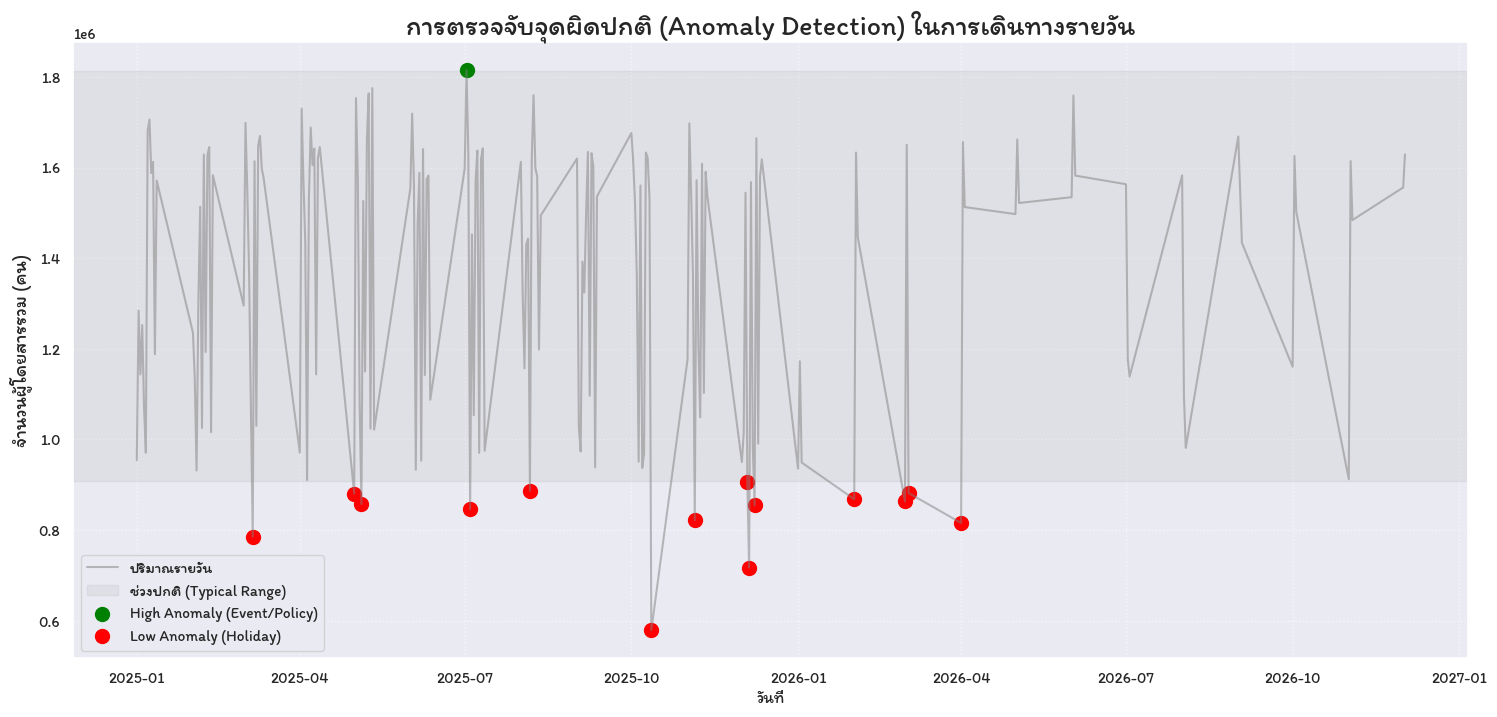

In [ ]:
# =============================================================
# CELL 23: Anomaly Detection
#
# วิธีการ: ใช้ Mean ± 1.5 * Std เป็น Threshold
#   - เกิน Upper Bound → อาจเป็นวันเทศกาล/Event พิเศษ
#   - ต่ำกว่า Lower Bound → อาจเป็นวันหยุดยาว/เหตุการณ์พิเศษ
#
# Cell นี้เป็นเวอร์ชัน 'Quick Preview' ก่อนวิเคราะห์ละเอียด
# =============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. รวมยอดผู้โดยสารทุกสายรายวัน (ภาพรวมระบบทั้งหมด)
daily_total = daily_passengers_individual_rail.groupby('วันที่')['ปริมาณ'].sum().reset_index()

# 2. คำนวณค่าสถิติพื้นฐาน
mean_val = daily_total['ปริมาณ'].mean()  # ค่าเฉลี่ยรายวัน
std_val = daily_total['ปริมาณ'].std()    # ส่วนเบี่ยงเบนมาตรฐาน

# กำหนด Threshold: เกิน 1.5 Std ถือว่า 'ผิดปกติ'
# เหตุผลที่ใช้ 1.5 (ไม่ใช่ 2 หรือ 3): เพื่อให้จับ anomaly ได้มากขึ้น
upper_bound = mean_val + (1.5 * std_val)  # Upper Threshold
lower_bound = mean_val - (1.5 * std_val)  # Lower Threshold

# 3. สร้างกราฟ Time Series พร้อม Anomaly Highlight
plt.figure(figsize=(18, 8))

# เส้นหลักแสดงปริมาณผู้โดยสาร (สีเทา + โปร่งใส)
sns.lineplot(data=daily_total, x='วันที่', y='ปริมาณ', color='gray', alpha=0.5, label='ปริมาณรายวัน')

# แรเงาช่วงปกติ
plt.axhspan(lower_bound, upper_bound, color='gray', alpha=0.1, label='ช่วงปกติ (Typical Range)')

# วงกลมสีเขียวที่จุดผิดปกติสูง
anomalies_high = daily_total[daily_total['ปริมาณ'] > upper_bound]
plt.scatter(anomalies_high['วันที่'], anomalies_high['ปริมาณ'], color='green', s=100, label='High Anomaly (Event/Policy)')

# วงกลมสีแดงที่จุดผิดปกติต่ำ
anomalies_low = daily_total[daily_total['ปริมาณ'] < lower_bound]
plt.scatter(anomalies_low['วันที่'], anomalies_low['ปริมาณ'], color='red', s=100, label='Low Anomaly (Holiday)')

# ตกแต่งกราฟ
plt.title('การตรวจจับจุดผิดปกติ (Anomaly Detection) ในการเดินทางรายวัน', fontsize=20, fontweight='bold')
plt.ylabel('จำนวนผู้โดยสารรวม (คน)', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()


ตรวจสอบจุดผิดปกติ (Anomaly) โดยใช้เกณฑ์ $\pm 1.5$ เท่าของส่วนเบี่ยงเบนมาตรฐาน (Std) เพื่อคัดกรองข้อมูลที่เบี่ยงเบนไปจากพฤติกรรมปกติ เนื่องจาก Std สามารถสะท้อน ความเสถียร (Stability) และการกระจายตัวของข้อมูลได้ชัดเจนกว่าค่าเฉลี่ย โดยพล็อตลงใน กราฟอนุกรมเวลา (Time-Series) เพื่อระบุความสัมพันธ์ระหว่างจุดที่ผิดปกติกับเหตุการณ์สำคัญ เช่น เทศกาล หรือนโยบายรัฐ

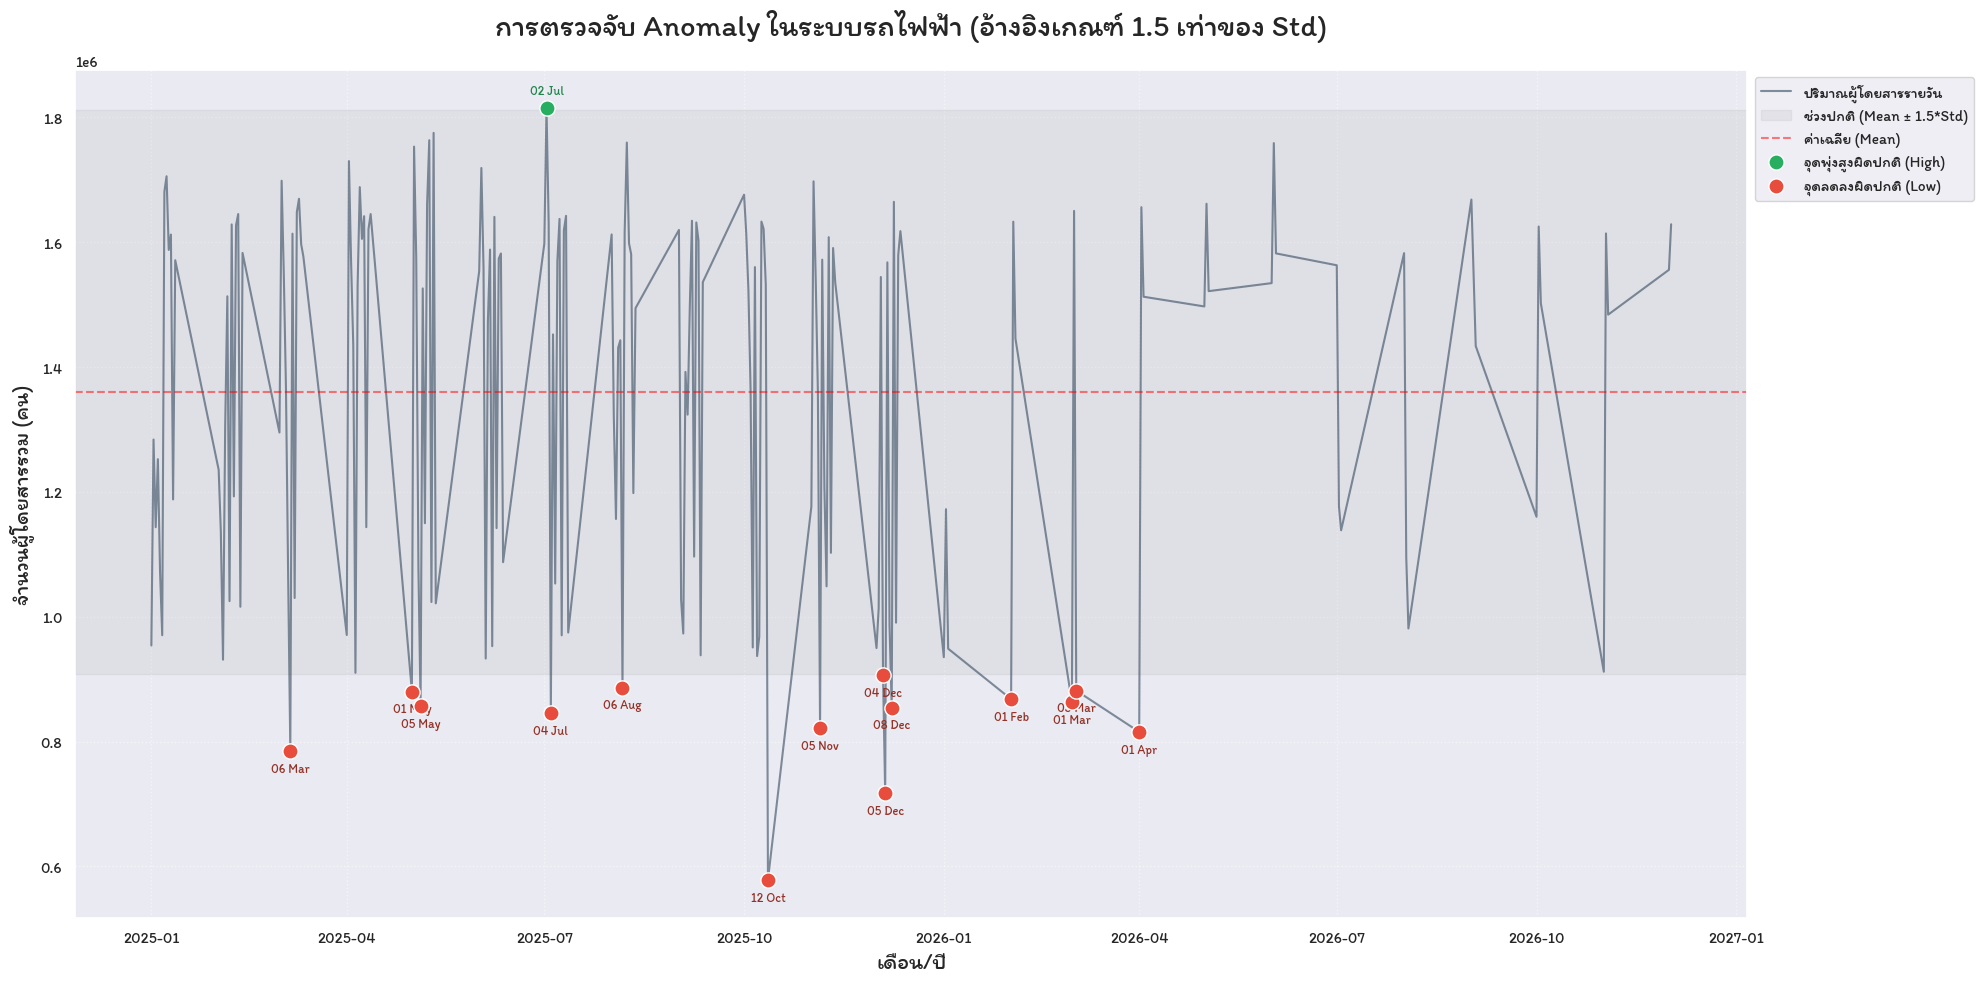


📅 รายการวันที่ตรวจพบความผิดปกติ (Anomaly List)


,วันที่,ปริมาณ,Type
29,2025-03-06 00:00:00,785265.000000,Low
48,2025-05-01 00:00:00,880142.000000,Low
52,2025-05-05 00:00:00,857279.000000,Low
73,2025-07-02 00:00:00,1814661.000000,High
75,2025-07-04 00:00:00,845650.000000,Low
89,2025-08-06 00:00:00,886629.000000,Low
119,2025-10-12 00:00:00,578746.000000,Low
124,2025-11-05 00:00:00,821702.000000,Low
135,2025-12-04 00:00:00,906778.000000,Low
136,2025-12-05 00:00:00,717088.000000,Low


In [ ]:
# =============================================================
# CELL 24: Anomaly Detection (เวอร์ชันละเอียด) + ตาราง Anomaly List
#
# เพิ่มจาก Cell ก่อน:
#   - แสดงเส้นค่าเฉลี่ย (Mean Line)
#   - Label วันที่บนจุด Anomaly
#   - แสดงตาราง Anomaly พร้อม Type (High/Low)
#
# หมายเหตุ: .background_gradient(subset=['Type']) ถูกลบออก
#            เพราะ 'Type' เป็น string ทำให้ gradient ไม่ work
# =============================================================

# 1. รวมยอดผู้โดยสารทุกสายรายวัน (คำนวณซ้ำเพื่อความชัดเจน)
daily_total = daily_passengers_individual_rail.groupby('วันที่')['ปริมาณ'].sum().reset_index()

# 2. คำนวณค่าสถิติและ Threshold (เหมือน Cell ก่อน)
mean_val = daily_total['ปริมาณ'].mean()
std_val = daily_total['ปริมาณ'].std()
upper_bound = mean_val + (1.5 * std_val)  # เกณฑ์บน
lower_bound = mean_val - (1.5 * std_val)  # เกณฑ์ล่าง

# กรองจุดผิดปกติออกเป็น DataFrame
high_anomalies = daily_total[daily_total['ปริมาณ'] > upper_bound]
low_anomalies = daily_total[daily_total['ปริมาณ'] < lower_bound]

# 3. สร้างกราฟ Time Series พร้อมรายละเอียดครบถ้วน
plt.figure(figsize=(20, 10))

# เส้นหลัก
sns.lineplot(data=daily_total, x='วันที่', y='ปริมาณ', color='#34495e', lw=1.5, label='ปริมาณผู้โดยสารรายวัน', alpha=0.6)

# แรเงาช่วงปกติ
plt.axhspan(lower_bound, upper_bound, color='gray', alpha=0.1, label='ช่วงปกติ (Mean ± 1.5*Std)')

# เส้นค่าเฉลี่ย
plt.axhline(mean_val, color='red', linestyle='--', alpha=0.5, label='ค่าเฉลี่ย (Mean)')

# จุด High Anomaly
plt.scatter(high_anomalies['วันที่'], high_anomalies['ปริมาณ'], color='#27ae60', s=120, edgecolors='white', zorder=5, label='จุดพุ่งสูงผิดปกติ (High)')

# จุด Low Anomaly
plt.scatter(low_anomalies['วันที่'], low_anomalies['ปริมาณ'], color='#e74c3c', s=120, edgecolors='white', zorder=5, label='จุดลดลงผิดปกติ (Low)')

# 4. ใส่ Label วันที่บนจุด Anomaly
#    strftime('%d %b') → แสดงวันที่แบบย่อ เช่น '01 Jan'
for i, row in high_anomalies.iterrows():
    plt.annotate(row['วันที่'].strftime('%d %b'),
                 (row['วันที่'], row['ปริมาณ']),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, fontweight='bold', color='#1e8449')

for i, row in low_anomalies.iterrows():
    plt.annotate(row['วันที่'].strftime('%d %b'),
                 (row['วันที่'], row['ปริมาณ']),
                 textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9, fontweight='bold', color='#943126')

# 5. ตกแต่งกราฟ
plt.title('การตรวจจับ Anomaly ในระบบรถไฟฟ้า (อ้างอิงเกณฑ์ 1.5 เท่าของ Std)', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('เดือน/ปี', fontsize=16)
plt.ylabel('จำนวนผู้โดยสารรวม (คน)', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# --- แสดงตาราง Anomaly List ---
print("\n" + "="*60)
print("📅 รายการวันที่ตรวจพบความผิดปกติ (Anomaly List)")
print("="*60)

# รวม High และ Low Anomaly → เรียงตามวันที่
# .assign(Type='High') → เพิ่มคอลัมน์ Type บอกว่าเป็น High หรือ Low
all_anomalies = pd.concat([high_anomalies.assign(Type='High'), low_anomalies.assign(Type='Low')])
all_anomalies = all_anomalies.sort_values('วันที่')

# หมายเหตุ: ลบ .background_gradient(subset=['Type']) ออก
#            เพราะ 'Type' เป็น string ไม่รองรับ gradient
display(all_anomalies[['วันที่', 'ปริมาณ', 'Type']].style)


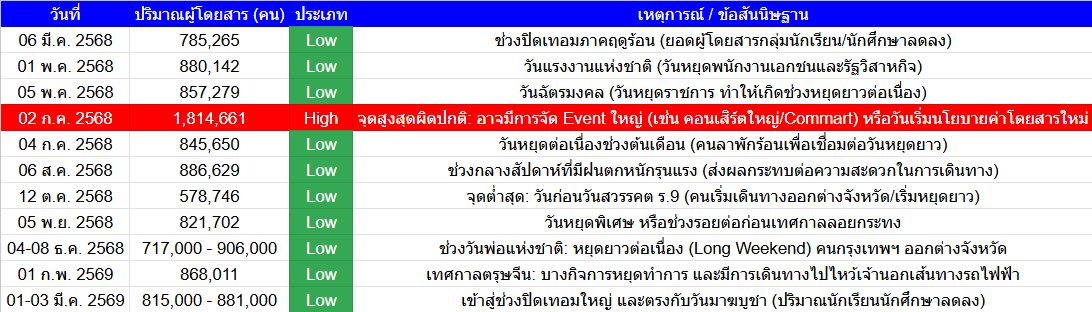